<a href="https://colab.research.google.com/github/michelletorres-lang/11.04.26_MVP-Final-An-lise-de-Dados-e-Boas-Pr-ticas-40530010055_20260_01-.ipynb/blob/main/11_04_26_MVP_Final_An%C3%A1lise_de_Dados_e_Boas_Pr%C3%A1ticas_(40530010055_20260_01).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Michelle Torres

**Matrícula:** 4052025000963

**Dataset:** [Controle Mensal da Qualidade da Água](https://github.com/michelletorres-lang/Qualidade-mensal-da-gua-do-RJ/blob/main/Qualidade%20Mensal%20%C3%81gua%20do%20RJ.xlsx)



# Descrição do Problema

O conjunto de dados apresentado, contém informações sobre o controle de qualidade da água em diversas localidades do estado do Rio de Janeiro referentes a janeiro de 2026. O objetivo principal é analisar os parâmetros básicos de qualidade da água, identificar possíveis anomalias, tendências ao longo do tempo e verificar a conformidade com padrões estabelecidos na Portaria GM/MS nº 888 de 2021. Com base nas novas hipóteses, buscaremos entender as relações entre diferentes tipos de desconformidades, o impacto do tipo de filtração na turbidez, e a variabilidade de conformidades/desconformidades entre os parâmetros.

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset Iris.

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [55]:
import pandas as pd

# Cole o link Raw entre as aspas
url = 'https://github.com/michelletorres-lang/Qualidade-mensal-da-gua-do-RJ/raw/main/Qualidade%20Mensal%20%C3%81gua%20do%20RJ.xlsx'
df = pd.read_excel(url)

In [56]:
# primeiras linhas
df.head()

,Região Geográfica,UF,Código IBGE,Município,Tipo da Instituição,Nome da Instituição,Nome do escritório regional/local,Tipo de Filtração,Ano de referência,Mês de referência,Ponto de Monitoramento,Parâmetro,Campo,Valor
0,SUDESTE,RJ,330015,APERIBE,Regional,AGUAS DO RIO 1 SPE SA,AGUAS DO RIO INTERIOR LAGOS,FILTRAÇÃO RÁPIDA,2026,1,SAÍDA DO TRATAMENTO,Fluoreto (mg/L),"Número de dados <= 1,5 mg/L",366.0
1,SUDESTE,RJ,330015,APERIBE,Regional,AGUAS DO RIO 1 SPE SA,AGUAS DO RIO INTERIOR LAGOS,FILTRAÇÃO RÁPIDA,2026,1,SAÍDA DO TRATAMENTO,Fluoreto (mg/L),Número de amostras analisadas,366.0
2,SUDESTE,RJ,330015,APERIBE,Regional,AGUAS DO RIO 1 SPE SA,AGUAS DO RIO INTERIOR LAGOS,FILTRAÇÃO RÁPIDA,2026,1,SAÍDA DO TRATAMENTO,Fluoreto (mg/L),Percentil 95,0.8
3,SUDESTE,RJ,330015,APERIBE,Regional,AGUAS DO RIO 1 SPE SA,AGUAS DO RIO INTERIOR LAGOS,FILTRAÇÃO RÁPIDA,2026,1,SAÍDA DO TRATAMENTO,Fluoreto (mg/L),"Número de dados > 1,5 mg/L",0.0
4,SUDESTE,RJ,330015,APERIBE,Regional,AGUAS DO RIO 1 SPE SA,AGUAS DO RIO INTERIOR LAGOS,FILTRAÇÃO RÁPIDA,2026,1,SAÍDA DO TRATAMENTO,Cloro Residual Livre (mg/L),"Número de dados > 5,0 mg/L",0.0


Ao observar as primeiras linhas do dataset, podemos notar:

*   **Colunas Descritivas:** As primeiras colunas (`Região Geográfica`, `UF`, `Município`, `Tipo da Instituição`, `Nome da Instituição`, `Nome do escritório regional/local`, `Tipo de Filtração`) fornecem informações contextuais sobre a origem e o monitoramento da amostra.
*   **Detalhes do Monitoramento:** `Ano de referência`, `Mês de referência`, `Ponto de Monitoramento`, `Parâmetro` e `Campo` detalham o que foi medido, onde e quando.
*   **`Valor` como Variável Chave:** A coluna `Valor` contém a medida numérica principal, mas seu significado exato é contextualizado pela coluna `Campo` (ex: 'Número de dados <= 1,5 mg/L', 'Percentil 95'). Isso sugere que o `Valor` não é uma medida direta do parâmetro, mas sim um agregado ou estatística relacionada a ele, o que é crucial para a interpretação.
*   **Repetição de Informações:** Observamos que várias linhas podem ter o mesmo `Município`, `Tipo de Filtração`, `Ano`, `Mês`, etc., mas diferentes `Parâmetro` e `Campo` (e, consequentemente, `Valor`). Isso confirma a estrutura 'longa' do dataset, onde cada linha é uma observação específica de um aspecto do monitoramento.
*   **Valores Nulos:** A coluna 'Nome do escritório regional/local' aparece como 'UNKNOWN' após o tratamento, indicando a presença original de valores nulos, que já foram abordados.

# Análise de Dados

Nesta etapa de Análise de Dados Exploratória (EDA) sobre o dataset Iris, visamos entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Total e Tipo das Instâncias

O dataset possui 10105 instâncias (observações). As colunas são uma mistura de tipos categóricos (object), numéricos inteiros (int64) e um numérico de ponto flutuante (float64) para o `Valor` medido.

In [57]:
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 10105

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10105 entries, 0 to 10104
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Região Geográfica                  10105 non-null  object 
 1   UF                                 10105 non-null  object 
 2   Código IBGE                        10105 non-null  int64  
 3   Município                          10105 non-null  object 
 4   Tipo da Instituição                10105 non-null  object 
 5   Nome da Instituição                10105 non-null  object 
 6   Nome do escritório regional/local  6080 non-null   object 
 7   Tipo de Filtração                  10105 non-null  object 
 8   Ano de referência                  10105 non-null  int64  
 9   Mês de referência                  10105 non-null  int64  
 10  Ponto de Monitoramento             10105 non-null  object 
 11 

## Hipóteses do Problema

As hipóteses que tracei são as seguintes, adaptadas ao dataset de qualidade da água:

1.  **Nos municípios onde a quantidade de desconformidades de cloro é maior também possui maior desconformidades de dos parâmetros microbiológicos coliformes totais e E. Coli?**

2.  **Existe uma correlação entre o `Valor` de turbidez desconformes e outras características do monitoramento, como o tipo de filtração?**

3.  **Alguns *Parâmetros* exibem uma maior variabilidade ou tendências incomuns nas quantidades de amostras conformes e desconformes em comparação com outros?**

## Tipo de Problema

Este é um problema de **análise descritiva**, **comparativa** e de **verificação de conformidade**. O objetivo principal é analisar a distribuição e relação de `Valores` e `Campos` para cada `Parâmetro` em busca de padrões, anomalias e para entender as interações entre diferentes aspectos do monitoramento de qualidade da água.

Observação: O problema não é supervisionado e nem não supervisionado. Embora algumas etapas de pré-processamento, como a padronização e a codificação, sejam comuns tanto em aprendizado supervisionado quanto não supervisionado, o objetivo principal aqui é a exploração e compreensão dos dados, e não a construção de um modelo preditivo.

## Seleção de Dados

O dataset foi carregado diretamente de um link do GitHub e já está pronto para uso. Não é necessária uma etapa de seleção de dados externa, mas pode ser necessário filtrar ou agregar dados para análises específicas.

## Atributos do Dataset

O dataset contém 10105 amostras e possui as seguintes colunas:

-   ***Região Geográfica*** (região do Brasil)
-   ***UF*** (Unidade Federativa)
-   ***Código IBGE*** (código do município pelo IBGE)
-   ***Município*** (nome do município)
-   ***Tipo da Instituição*** (tipo da instituição responsável pelo monitoramento)
-   ***Nome da Instituição*** (nome da instituição)
-   ***Nome do escritório regional/local*** (nome do escritório regional ou local)
-   ***Tipo de Filtração*** (tipo de filtração da água)
-   ***Ano de referência*** (ano do monitoramento)
-   ***Mês de referência*** (mês do monitoramento)
-   ***Ponto de Monitoramento*** (local específico do monitoramento, ex: SAÍDA DO TRATAMENTO)
-   ***Parâmetro*** (nome do parâmetro de qualidade da água medido, ex: Fluoreto, Cloro Residual Livre) - **Esta será nossa coluna central para análise e agrupamento**
-   ***Campo*** (descrição do tipo de dado do parâmetro, ex: Número de dados <= 1,5 mg/L)
-   ***Valor*** (valor numérico medido para o parâmetro em questão) - **Esta é a principal medida numérica**

## Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [58]:
# Estatísticas descritivas agrupadas por Parâmetro, focando no 'Valor', e incluindo o percentil 95
df.groupby('Parâmetro')['Valor'].describe(percentiles=[.25, .50, .75, .95])

,count,mean,std,min,25%,50%,75%,95%,max
Parâmetro,,,,,,,,,
Cloro Residual Livre (mg/L),1702.0,125.839582,221.541671,0.0,0.00,2.00,240.0,638.00,1440.0
Coliformes totais,962.0,5.646570,6.144957,0.0,0.00,5.00,8.0,13.95,51.0
Cor (uH),1512.0,145.538502,224.942727,0.0,0.00,8.00,327.0,654.00,1440.0
Escherichia coli,964.0,5.670124,6.343663,0.0,0.00,5.00,8.0,14.00,51.0
Fluoreto (mg/L),1571.0,101.635509,193.075873,0.0,0.00,3.00,168.0,379.00,1440.0
Turbidez (uT),2773.0,205.266795,423.415261,0.0,0.35,4.23,318.0,898.20,5952.0
pH,621.0,182.123994,225.505509,0.0,4.00,24.00,342.0,665.00,1080.0


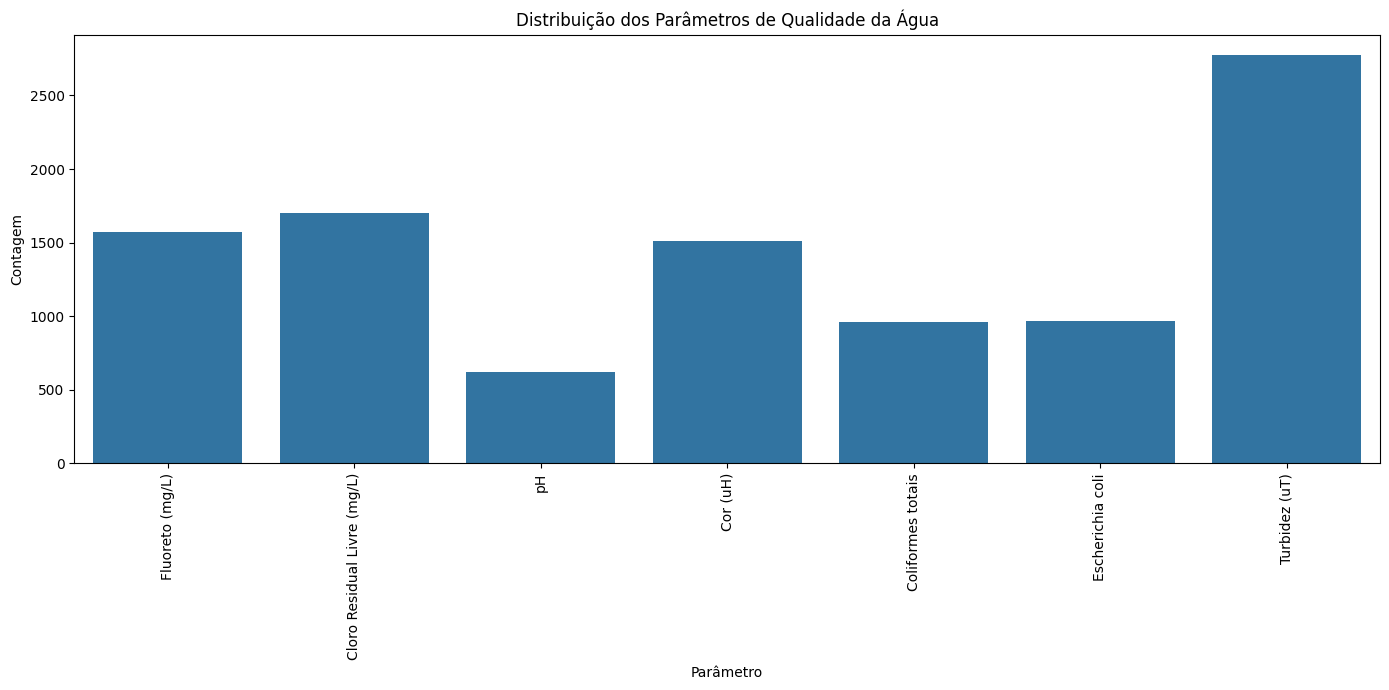

In [59]:
plt.figure(figsize=(14, 7))
sns.countplot(x='Parâmetro', data=df)
plt.title('Distribuição dos Parâmetros de Qualidade da Água')
plt.xlabel('Parâmetro')
plt.ylabel('Contagem')
plt.xticks(rotation=90)
plt.tight_layout() # Ajusta o layout para evitar sobreposição de rótulos
plt.show()

O gráfico de barras mostra a contagem de registros para cada `Parâmetro` de qualidade da água. Podemos observar a frequência com que cada parâmetro foi monitorado, indicando quais são mais ou menos presentes no dataset. A grande quantidade de categorias demonstra a diversidade de análises realizadas.

### Média dos Percentis 95 por Parâmetro

Foi possível calcular apenas a média dos dos valores de 'Percentil 95' para cada `Parâmetro`, tendo em vista que no dataset não há exibibizção dos resultados e sim os percentis. Obs.: O 'Percentil 95' é uma medida importante que indica que 95% dos valores observados estão abaixo desse ponto, sendo útil para avaliar a distribuição dos dados e identificar limites superiores. Obs.2: Como os resultados dos parâmetros microbiológicos são categóricos, presença/ausência, também não foi possível calcular média.

In [60]:
# Filtrar o DataFrame para 'Percentil 95'
df_percentil_95 = df[df['Campo'] == 'Percentil 95']

# Calcular a média do 'Valor' para cada 'Parâmetro'
media_percentil_95 = df_percentil_95.groupby('Parâmetro')['Valor'].mean().reset_index()
media_percentil_95.rename(columns={'Valor': 'Media_Percentil_95'}, inplace=True)

print("Média dos valores de Percentil 95 por Parâmetro:")
display(media_percentil_95)

Média dos valores de Percentil 95 por Parâmetro:


,Parâmetro,Media_Percentil_95
0,Cloro Residual Livre (mg/L),2.276560
1,Cor (uH),7.580044
2,Fluoreto (mg/L),0.817628
3,Turbidez (uT),1.763509


/tmp/ipykernel_4657/2092199753.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Parâmetro', y='Media_Percentil_95', data=media_percentil_95, palette='viridis')


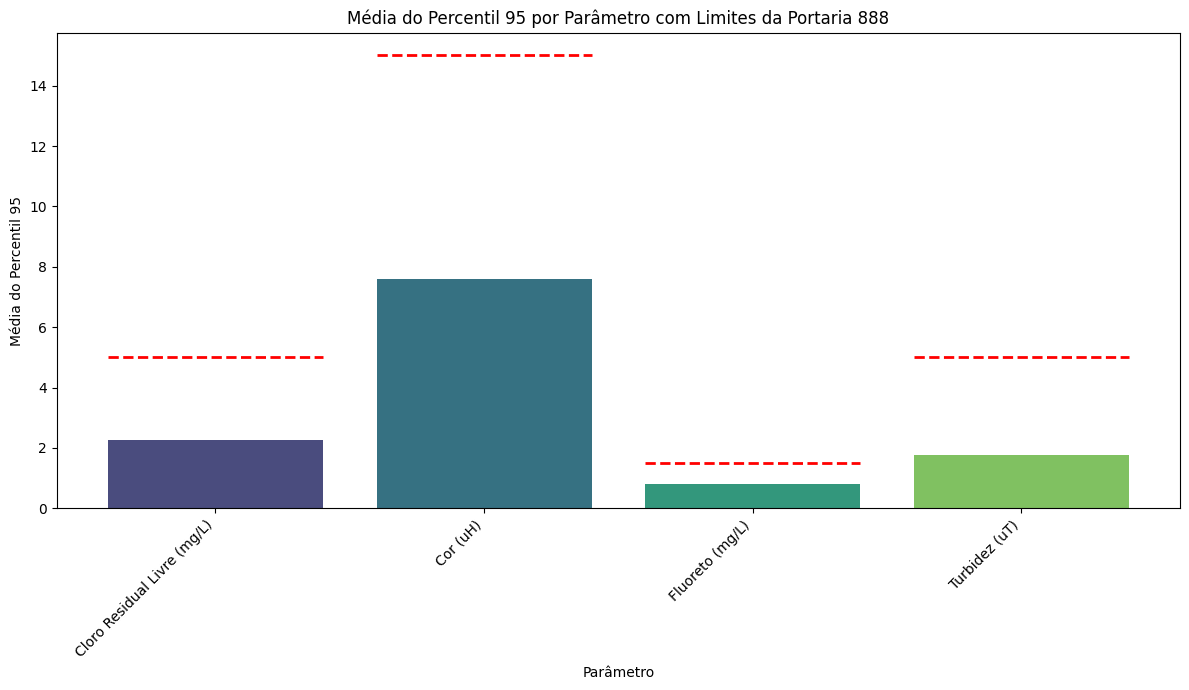

In [61]:
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Parâmetro', y='Media_Percentil_95', data=media_percentil_95, palette='viridis')

# Definir os limites da Portaria 888 para os parâmetros relevantes
limites_portaria_888 = {
    'Cloro Residual Livre (mg/L)': 5.0,
    'Cor (uH)': 15.0,
    'Fluoreto (mg/L)': 1.5,
    'Turbidez (uT)': 5.0
}

# Adicionar linhas de limite ao gráfico
for param, limit in limites_portaria_888.items():
    if param in media_percentil_95['Parâmetro'].values:
        # Encontrar a posição x do parâmetro no gráfico
        x_pos = media_percentil_95[media_percentil_95['Parâmetro'] == param].index[0]

        # Adicionar a linha horizontal
        ax.hlines(y=limit, xmin=x_pos - 0.4, xmax=x_pos + 0.4, colors='red', linestyles='--', linewidth=2, label=f'Limite Portaria 888 ({param})')

        # Adicionar texto para o limite (opcional, pode ser sobrecarregado)
        # ax.text(x_pos, limit + 0.1, f'{limit}', color='red', ha='center', va='bottom')

plt.title('Média do Percentil 95 por Parâmetro com Limites da Portaria 888')
plt.xlabel('Parâmetro')
plt.ylabel('Média do Percentil 95')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

No gráfico, podemos observar claramente a média do Percentil 95 para cada parâmetro e compará-la com o limite estabelecido pela Portaria 888. As linhas vermelhas servem como um guia visual rápido para os vaores máximos permitidos para cada parâmetro:

Para o Cloro Residual Livre (mg/L), a média do Percentil 95 está bem abaixo do limite de 5.0 mg/L, indicando que a maioria das amostras está em conformidade com esse aspecto.
Para a Cor (uH), a média do Percentil 95 está significativamente abaixo do limite de 15.0 uH, sugerindo boa conformidade.
Para o Fluoreto (mg/L), a média do Percentil 95 também está abaixo do limite de 1.5 mg/L.
Para a Turbidez (uT), a média do Percentil 95 aparece bem abaixo do limite de 5.0 uT.
Isso sugere que, em média, o Percentil 95 para esses parâmetros está dentro dos limites da Portaria 888, o que é um bom indicador da qualidade da água em relação a esses critérios.

### Desvio Padrão do Percentil 95 por Parâmetro

Agora, vamos calcular o desvio padrão dos valores do 'Percentil 95' para cada `Parâmetro`. Isso nos ajudará a entender a consistência (ou variabilidade) do limite de 95% das medições para cada tipo de análise.

In [62]:
# Calcular o desvio padrão do 'Valor' para cada 'Parâmetro' no DataFrame filtrado por 'Percentil 95'
desvio_padrao_percentil_95 = df_percentil_95.groupby('Parâmetro')['Valor'].std().reset_index()
desvio_padrao_percentil_95.rename(columns={'Valor': 'Desvio_Padrao_Percentil_95'}, inplace=True)

print("Desvio Padrão dos valores de Percentil 95 por Parâmetro:")
display(desvio_padrao_percentil_95)

Desvio Padrão dos valores de Percentil 95 por Parâmetro:


,Parâmetro,Desvio_Padrao_Percentil_95
0,Cloro Residual Livre (mg/L),0.895440
1,Cor (uH),7.700496
2,Fluoreto (mg/L),0.224870
3,Turbidez (uT),2.544747


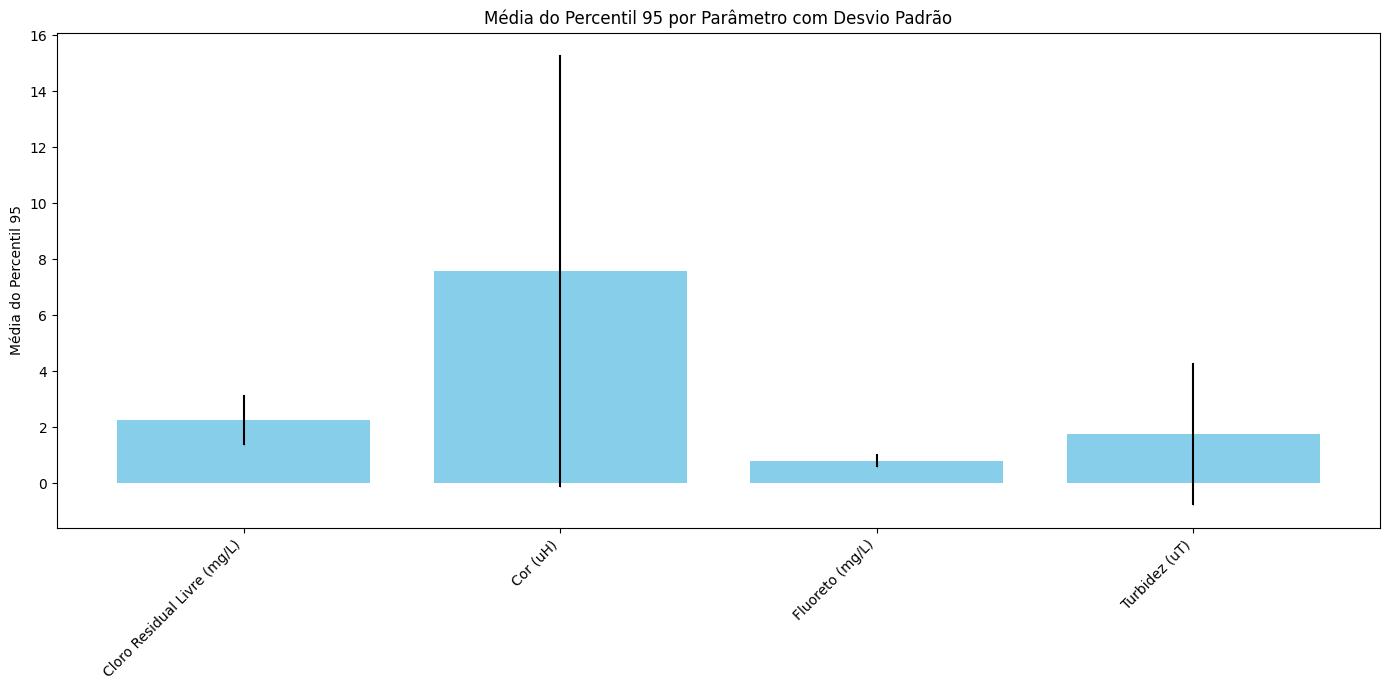

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# Criar o DataFrame comparativo_percentil_95 combinando a média e o desvio padrão
comparativo_percentil_95 = media_percentil_95.merge(desvio_padrao_percentil_95, on='Parâmetro', how='left')

# Data from comparativo_percentil_95
parameters = comparativo_percentil_95['Parâmetro']
means = comparativo_percentil_95['Media_Percentil_95']
stds = comparativo_percentil_95['Desvio_Padrao_Percentil_95']

x_pos = np.arange(len(parameters))

plt.figure(figsize=(14, 7))
plt.bar(x_pos, means, yerr=stds, capsize=0.1, color='skyblue')
plt.ylabel('Média do Percentil 95')
plt.title('Média do Percentil 95 por Parâmetro com Desvio Padrão')
plt.xticks(x_pos, parameters, rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Desvio Padrão - Conclusão

O desvio padrão dos valores de Percentil 95 por Parâmetro foi calculado e é exibido na tabela. Isso nos ajuda a entender a variabilidade ou consistência dos dados para cada parâmetro. Por exemplo, a 'Cor (uH)' tem o maior desvio padrão, indicando maior variabilidade nos seus valores de Percentil 95, enquanto o 'Fluoreto (mg/L)' tem o menor. Isso sugere que os níveis de fluoreto são mais consistentes em seus limites superiores do que os de cor. O gráfico de barras mostra a média do Percentil 95 para cada parâmetro, com barras de erro que representam o desvio padrão. Podemos observar visualmente a variabilidade de cada parâmetro. Por exemplo, a 'Cor (uH)' apresenta não apenas a maior média do Percentil 95, mas também a maior barra de erro, indicando uma variabilidade significativa nos seus dados. Em contraste, o 'Fluoreto (mg/L)' tem a menor média e o menor desvio padrão, sugerindo uma maior consistência nos valores do Percentil 95. Este gráfico nos ajuda a identificar rapidamente quais parâmetros são mais estáveis e quais possuem maior dispersão em seus limites superiores.

## Histograma

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). O histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais.

### Histograma do Percentil 95 para Cloro Residual Livre (mg/L)

Com base na média de aproximadamente 2.28 mg/L e um desvio padrão de cerca de 0.89 mg/L (informações já calculadas), e considerando que o limite da Portaria 888 é de 5.0 mg/L, é provável que o histograma mostre uma concentração de valores na parte inferior do eixo, bem abaixo do limite regulatório. A distribuição deve ser predominantemente unimodal, possivelmente com uma ligeira assimetria à direita, indicando que a maioria dos locais monitorados mantém o Percentil 95 do cloro residual livre em níveis consistentemente baixos e bem dentro da conformidade. Isso sugere uma boa gestão e estabilidade nos níveis de cloro residual livre.

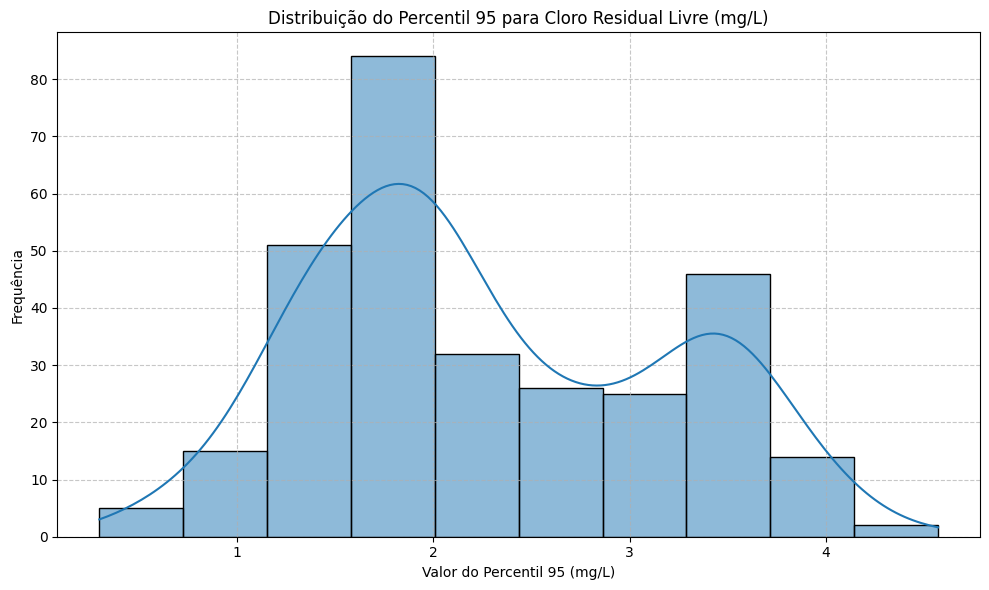

In [64]:
# Filtrar para o parâmetro 'Cloro Residual Livre (mg/L)' e campo 'Percentil 95'
df_cloro_percentil_95 = df_percentil_95[df_percentil_95['Parâmetro'] == 'Cloro Residual Livre (mg/L)']

plt.figure(figsize=(10, 6))
sns.histplot(df_cloro_percentil_95['Valor'], kde=True, bins=10)
plt.title('Distribuição do Percentil 95 para Cloro Residual Livre (mg/L)')
plt.xlabel('Valor do Percentil 95 (mg/L)')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Histograma do Percentil 95 para Cor (uH)

Vamos agora visualizar a distribuição do Percentil 95 para o parâmetro 'Cor (uH)'. Com base na média de aproximadamente 7.58 uH e um desvio padrão de cerca de 7.70 uH (informações já calculadas), e considerando que o limite da Portaria 888 é de 15.0 uH, o histograma deve nos dar uma ideia da distribuição dos valores desse parâmetro em relação ao limite regulatório. A alta variabilidade (desvio padrão elevado) pode sugerir uma distribuição mais espalhada em comparação com outros parâmetros.

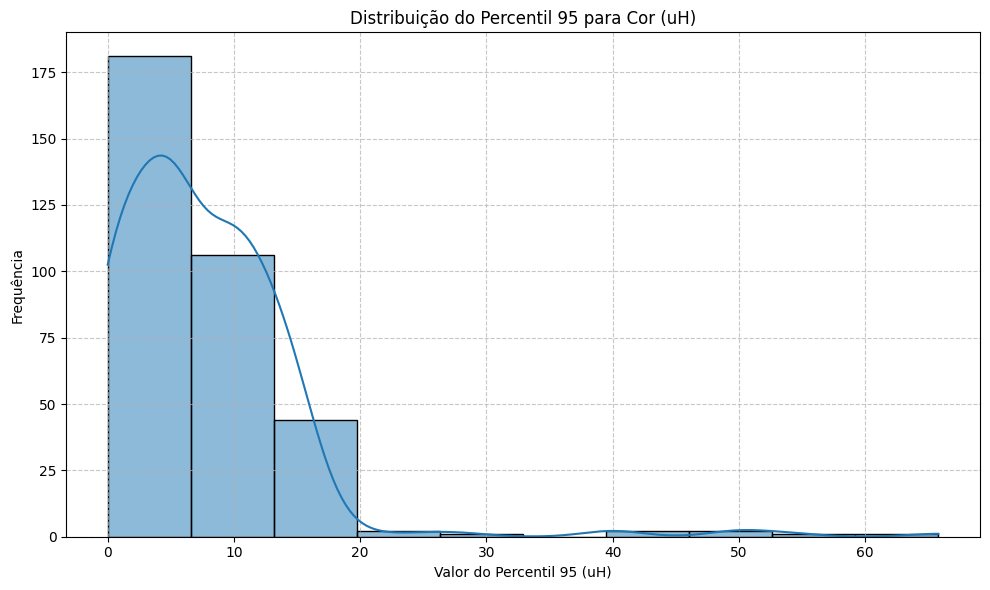

In [65]:
# Filtrar para o parâmetro 'Cor (uH)' e campo 'Percentil 95'
df_cor_percentil_95 = df_percentil_95[df_percentil_95['Parâmetro'] == 'Cor (uH)']

plt.figure(figsize=(10, 6))
sns.histplot(df_cor_percentil_95['Valor'], kde=True, bins=10)
plt.title('Distribuição do Percentil 95 para Cor (uH)')
plt.xlabel('Valor do Percentil 95 (uH)')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Histograma do Percentil 95 para Turbidez (uT)

Agora, vamos visualizar a distribuição do Percentil 95 para o parâmetro 'Turbidez (uT)'. Com base na média de aproximadamente 1.76 uT e um desvio padrão de cerca de 2.54 uT (informações já calculadas), e considerando que o limite da Portaria 888 é de 5.0 uT, o histograma nos dará uma perspectiva sobre como os valores desse parâmetro se distribuem em relação ao limite regulatório. A variabilidade observada e a concentração dos dados são importantes para entender a conformidade da água neste aspecto.

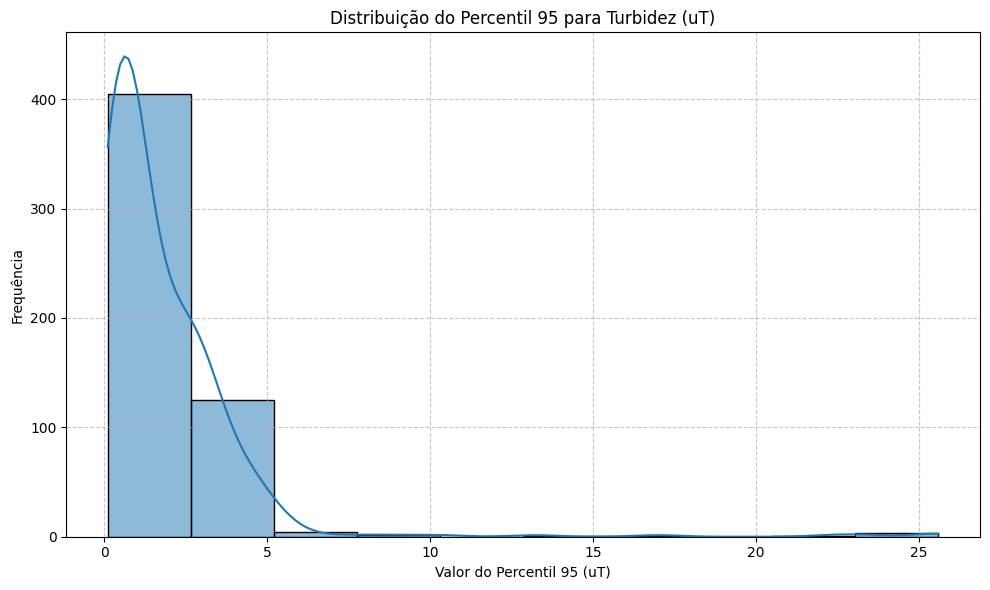

In [66]:
# Filtrar para o parâmetro 'Turbidez (uT)' e campo 'Percentil 95'
df_turbidez_percentil_95 = df_percentil_95[df_percentil_95['Parâmetro'] == 'Turbidez (uT)']

plt.figure(figsize=(10, 6))
sns.histplot(df_turbidez_percentil_95['Valor'], kde=True, bins=10)
plt.title('Distribuição do Percentil 95 para Turbidez (uT)')
plt.xlabel('Valor do Percentil 95 (uT)')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Boxplot

Este boxplot visualiza a distribuição dos valores do 'Percentil 95' para cada `Parâmetro`, permitindo-nos observar a mediana, os quartis e quaisquer outliers nos dados do Percentil 95.

/tmp/ipykernel_4657/3021726785.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Parâmetro', y='Valor', data=df_percentil_95, palette='viridis')


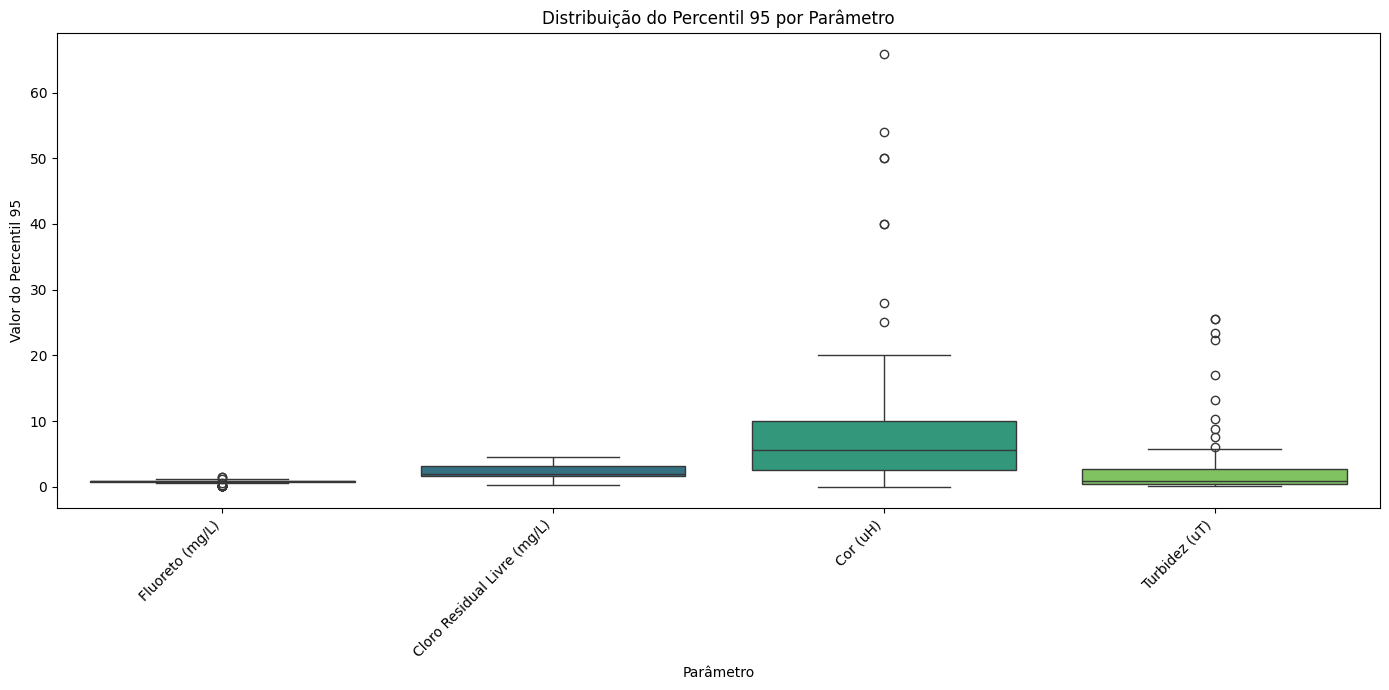

In [67]:
plt.figure(figsize=(14, 7))
sns.boxplot(x='Parâmetro', y='Valor', data=df_percentil_95, palette='viridis')
plt.title('Distribuição do Percentil 95 por Parâmetro')
plt.xlabel('Parâmetro')
plt.ylabel('Valor do Percentil 95')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###Boxplot comentário
O boxplot mostra a distribuição dos `Valores` para cada `Parâmetro`. Em resumo, o boxplot apresenta a estabilidade do Fluoreto, a variabilidade moderada de Turbidez e Cloro, e a alta variabilidade da Cor, com a presença de outliers em quase todos os parâmetros que merecem investigação para entender as causas

## Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos das espécies podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

### Matriz de Correlação dos Percentis 95 entre Parâmetros por Município

Vamos agora criar uma matriz de correlação que explore a relação entre os valores do Percentil 95 de cada `Parâmetro` em diferentes `Municípios`. Isso nos permitirá verificar se, por exemplo, municípios com alto Percentil 95 para 'Cor' também tendem a ter alto Percentil 95 para 'Turbidez', sugerindo relações entre as características da água ou a eficiência do tratamento.

Primeiras 5 linhas do DataFrame pivotado (Percentil 95 por Parâmetro e Município):


Parâmetro,Cloro Residual Livre (mg/L),Cor (uH),Fluoreto (mg/L),Turbidez (uT)
Município,,,,
APERIBE,1.44,13.6,0.80,0.470
ARARUAMA,2.80,1.0,0.80,0.300
BARRA DO PIRAI,4.00,65.8,NaN,22.375
BOM JESUS DO ITABAPOANA,2.50,1.0,NaN,0.700
CACHOEIRAS DE MACACU,1.80,14.0,1.03,2.010



Matriz de Correlação entre os Percentis 95 dos Parâmetros:


Parâmetro,Cloro Residual Livre (mg/L),Cor (uH),Fluoreto (mg/L),Turbidez (uT)
Parâmetro,,,,
Cloro Residual Livre (mg/L),1.000000,0.293809,-0.153326,0.349217
Cor (uH),0.293809,1.000000,-0.001030,0.618433
Fluoreto (mg/L),-0.153326,-0.001030,1.000000,-0.284723
Turbidez (uT),0.349217,0.618433,-0.284723,1.000000


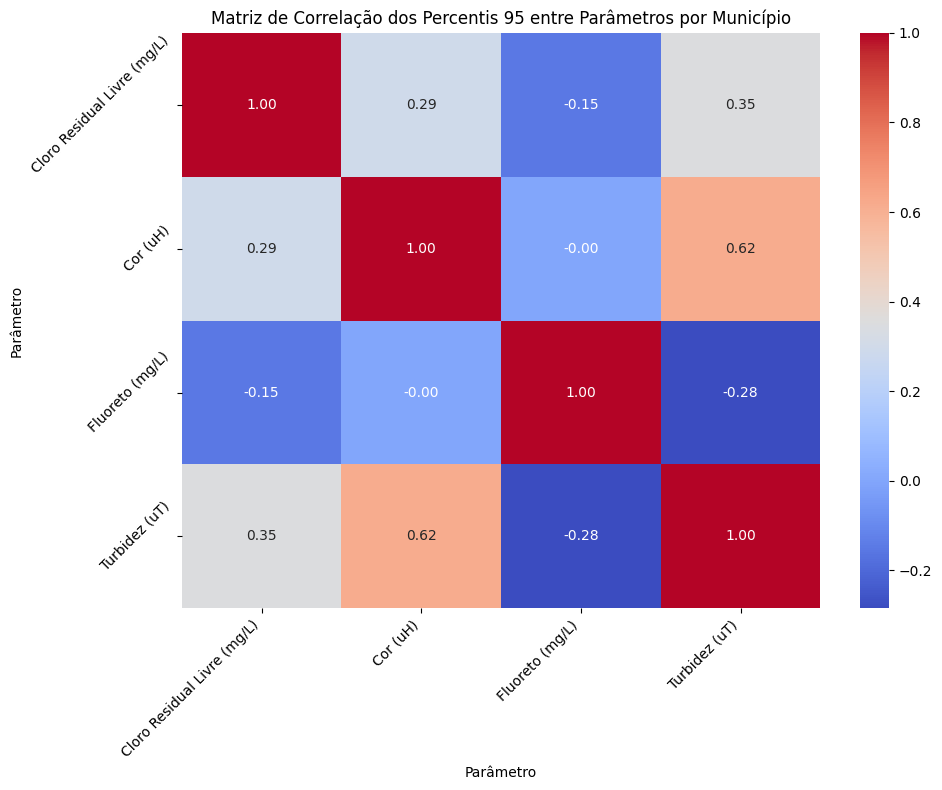

In [68]:
# Pivotar o DataFrame df_percentil_95 para que os parâmetros sejam colunas e os municípios sejam as linhas
# Usamos aggfunc='first' porque, idealmente, há um único valor de 'Percentil 95' por parâmetro por município. Se houver mais de um, 'mean' ou 'median' também poderiam ser usados.
df_percentil_99_pivot = df_percentil_95.pivot_table(index='Município', columns='Parâmetro', values='Valor', aggfunc='first')

print("Primeiras 5 linhas do DataFrame pivotado (Percentil 95 por Parâmetro e Município):")
display(df_percentil_99_pivot.head())

# Calcular a matriz de correlação
correlation_matrix_percentil_95 = df_percentil_99_pivot.corr()

print("\nMatriz de Correlação entre os Percentis 95 dos Parâmetros:")
display(correlation_matrix_percentil_95)

# Visualizar a matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_percentil_95, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação dos Percentis 95 entre Parâmetros por Município')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

###Matriz de Correlação dos Percentis 95 - Conclusão

A matriz de correlação e o mapa de calor acima mostram as relações lineares entre os valores do Percentil 95 de cada parâmetro de qualidade da água, considerando a variação desses valores entre os municípios.

*   **Correlações Positivas Fortes (próximo de 1):** Indicam que quando o Percentil 95 de um parâmetro é alto em um município, o Percentil 95 do outro parâmetro também tende a ser alto nesse mesmo município. Por exemplo, uma correlação alta entre 'Cor (uH)' e 'Turbidez (uT)' seria esperada, pois ambos podem estar relacionados à presença de partículas na água.
*   **Correlações Negativas Fortes (próximo de -1):** Sugerem que quando o Percentil 95 de um parâmetro é alto, o do outro tende a ser baixo.
*   **Correlações Próximas de 0:** Indicam que não há uma relação linear forte entre os Percentis 95 dos dois parâmetros.

Essa análise é crucial para identificar parâmetros que se comportam de forma similar ou oposta em termos de seus limites superiores, o que pode direcionar investigações mais aprofundadas sobre as causas dessas interações e a eficácia das medidas de tratamento.

### Matriz de Correlação: Cloro vs. Parâmetros Microbiológicos

Agora vamos calcular a matriz de correlação entre as desconformidades de Cloro Residual Livre, Coliformes totais e Escherichia coli por município. Esta análise nos ajuda a entender se os municípios com maior problema em um desses parâmetros também tendem a ter problemas nos outros.

Para isso, primeiramente, precisamos identificar e somar as desconformidades para cada um desses parâmetros em cada município, utilizando os critérios definidos na 'Hipótese 1' do notebook.

In [69]:
# Identificar as desconformidades para Cloro Residual Livre (< 0,2 mg/L)
df_cloro_desconforme = df[
    (df['Parâmetro'] == 'Cloro Residual Livre (mg/L)') &
    (df['Campo'].str.contains('< 0,2 mg/L', na=False))
]
cloro_desconforme_por_municipio = df_cloro_desconforme.groupby('Município')['Valor'].sum().reset_index()
cloro_desconforme_por_municipio.rename(columns={'Valor': 'Desconformidades_Cloro'}, inplace=True)

# Identificar as desconformidades para Coliformes totais (presença)
df_coliformes_desconforme = df[
    (df['Parâmetro'] == 'Coliformes totais') &
    (df['Campo'].str.contains('presença', na=False) | df['Campo'].str.contains('> 0', na=False))
]
coliformes_desconforme_por_municipio = df_coliformes_desconforme.groupby('Município')['Valor'].sum().reset_index()
coliformes_desconforme_por_municipio.rename(columns={'Valor': 'Desconformidades_Coliformes'}, inplace=True)

# Identificar as desconformidades para Escherichia coli (presença)
df_ecoli_desconforme = df[
    (df['Parâmetro'] == 'Escherichia coli') &
    (df['Campo'].str.contains('presença', na=False) | df['Campo'].str.contains('> 0', na=False))
]
ecoli_desconforme_por_municipio = df_ecoli_desconforme.groupby('Município')['Valor'].sum().reset_index()
ecoli_desconforme_por_municipio.rename(columns={'Valor': 'Desconformidades_EColi'}, inplace=True)

# Unir os resultados por município
df_hipotese1_recalc = cloro_desconforme_por_municipio.merge(
    coliformes_desconforme_por_municipio, on='Município', how='outer'
).merge(
    ecoli_desconforme_por_municipio, on='Município', how='outer'
).fillna(0)

print("Desconformidades por Município (Cloro, Coliformes, E. Coli) para Correlação:")
display(df_hipotese1_recalc.head())

Desconformidades por Município (Cloro, Coliformes, E. Coli) para Correlação:


,Município,Desconformidades_Cloro,Desconformidades_Coliformes,Desconformidades_EColi
0,ANGRA DOS REIS,0.0,0.0,0.0
1,APERIBE,0.0,0.0,0.0
2,ARARUAMA,0.0,0.0,0.0
3,AREAL,0.0,0.0,0.0
4,BARRA DO PIRAI,0.0,0.0,0.0


Agora, com os dados de desconformidades agregados por município, podemos calcular a matriz de correlação e visualizá-la.

Matriz de Correlação das Desconformidades (Cloro, Coliformes, E. Coli):


,Desconformidades_Cloro,Desconformidades_Coliformes,Desconformidades_EColi
Desconformidades_Cloro,1.000000,-0.044998,-0.048274
Desconformidades_Coliformes,-0.044998,1.000000,0.062593
Desconformidades_EColi,-0.048274,0.062593,1.000000


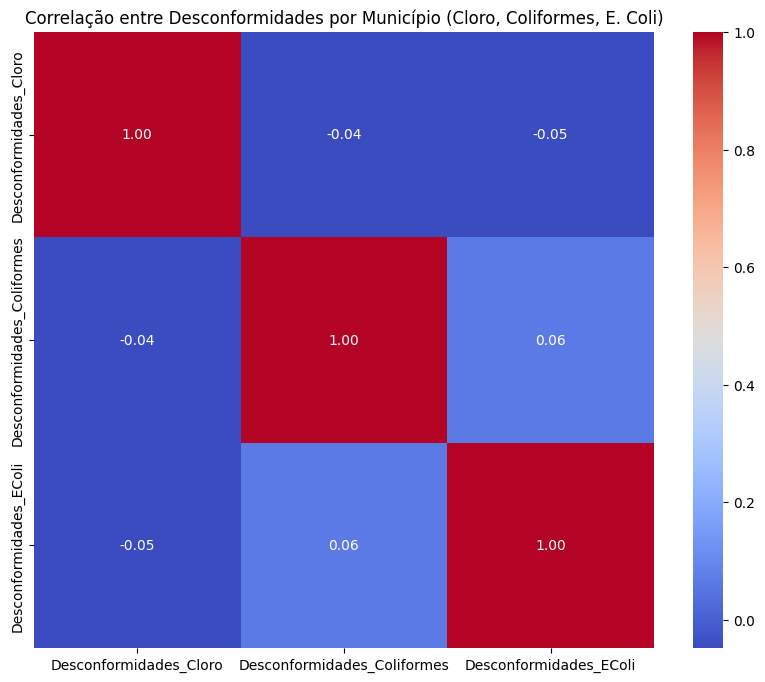

In [70]:
# Calcular a matriz de correlação
correlation_matrix_cloro_micro = df_hipotese1_recalc[['Desconformidades_Cloro', 'Desconformidades_Coliformes', 'Desconformidades_EColi']].corr()

print("Matriz de Correlação das Desconformidades (Cloro, Coliformes, E. Coli):")
display(correlation_matrix_cloro_micro)

# Visualizar a correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix_cloro_micro, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlação entre Desconformidades por Município (Cloro, Coliformes, E. Coli)')
plt.show()

### Conclusão A matriz de correlação e o mapa de calor acima mostram as relações lineares entre as quantidades de desconformidades de Cloro Residual Livre, Coliformes totais e Escherichia coli entre os municípios. Valores próximos a 1 indicam uma forte correlação positiva, enquanto valores próximos a 0 sugerem pouca ou nenhuma correlação linear.

## Tratamento de Valores Nulos

O dataset possui valores nulos na coluna `Nome do escritório regional/local`. O tratamento de valores nulos é crucial e pode envolver imputação (preenchimento com média, mediana, moda) ou remoção de linhas/colunas.

In [71]:
import pandas as pd

# Cole o link Raw entre as aspas
url = 'https://github.com/michelletorres-lang/Qualidade-mensal-da-gua-do-RJ/raw/main/Qualidade%20Mensal%20%C3%81gua%20do%20RJ.xlsx'
df = pd.read_excel(url)

# Verificar a presença de valores nulos no dataset original
print("Valores nulos no dataset:")
df_copy = df.copy()
df_copy['Nome do escritório regional/local'] = df_copy['Nome do escritório regional/local'].fillna('UNKNOWN')
display(df_copy.isnull().sum())

Valores nulos no dataset:


,0
Região Geográfica,0
UF,0
Código IBGE,0
Município,0
Tipo da Instituição,0
Nome da Instituição,0
Nome do escritório regional/local,0
Tipo de Filtração,0
Ano de referência,0
Mês de referência,0


In [72]:
#correlação de pearson
df[['Código IBGE', 'Ano de referência', 'Mês de referência', 'Valor']].corr(method='pearson')

,Código IBGE,Ano de referência,Mês de referência,Valor
Código IBGE,1.000000,NaN,-0.013472,0.001770
Ano de referência,NaN,NaN,NaN,NaN
Mês de referência,-0.013472,NaN,1.000000,0.007178
Valor,0.001770,NaN,0.007178,1.000000


### Número de Amostras Analisadas por Parâmetro

Vamos extrair o 'Número de amostras analisadas' para cada 'Parâmetro' e somar os valores, o que nos dará uma visão do volume de monitoramento para cada um.

In [73]:
# Filtrar as linhas onde 'Campo' indica 'Número de amostras analisadas'
df_amostras_analisadas = df[df['Campo'] == 'Número de amostras analisadas']

# Agrupar por 'Parâmetro' e somar os 'Valor' para obter o total de amostras analisadas
total_amostras_por_parametro = df_amostras_analisadas.groupby('Parâmetro')['Valor'].sum().reset_index()
total_amostras_por_parametro.rename(columns={'Valor': 'Total de Amostras Analisadas'}, inplace=True)

print("Total de Amostras Analisadas por Parâmetro:")
display(total_amostras_por_parametro)

Total de Amostras Analisadas por Parâmetro:


,Parâmetro,Total de Amostras Analisadas
0,Cloro Residual Livre (mg/L),106748.0
1,Coliformes totais,2703.0
2,Cor (uH),109102.0
3,Escherichia coli,2729.0
4,Fluoreto (mg/L),60538.0
5,Turbidez (uT),285931.0
6,pH,93217.0


### Estatísticas Descritivas do 'Valor' por Parâmetro (Revisão)

Conforme já explorado na célula `iH6ov-UMHHHJ`, as estatísticas descritivas do 'Valor' para cada 'Parâmetro' fornecem um resumo da distribuição dos valores medidos, incluindo média, desvio padrão, mínimo, máximo e quartis. Isso nos ajuda a entender a faixa e a variabilidade dos dados para cada parâmetro. É importante notar que o 'Valor' pode representar diferentes métricas (como 'Percentil 95', 'Número de dados', etc.), dependendo do 'Campo' associado, e essas estatísticas são calculadas sobre todos esses tipos de 'Valor' para cada parâmetro.

In [74]:
# Reexibir as estatísticas descritivas agrupadas por Parâmetro, focando no 'Valor'
display(df.groupby('Parâmetro')['Valor'].describe(percentiles=[.25, .50, .75, .95]))

,count,mean,std,min,25%,50%,75%,95%,max
Parâmetro,,,,,,,,,
Cloro Residual Livre (mg/L),1702.0,125.839582,221.541671,0.0,0.00,2.00,240.0,638.00,1440.0
Coliformes totais,962.0,5.646570,6.144957,0.0,0.00,5.00,8.0,13.95,51.0
Cor (uH),1512.0,145.538502,224.942727,0.0,0.00,8.00,327.0,654.00,1440.0
Escherichia coli,964.0,5.670124,6.343663,0.0,0.00,5.00,8.0,14.00,51.0
Fluoreto (mg/L),1571.0,101.635509,193.075873,0.0,0.00,3.00,168.0,379.00,1440.0
Turbidez (uT),2773.0,205.266795,423.415261,0.0,0.35,4.23,318.0,898.20,5952.0
pH,621.0,182.123994,225.505509,0.0,4.00,24.00,342.0,665.00,1080.0


# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

In [75]:
# Separar features (X) e target (y)
# 'Parâmetro' é definido como a variável alvo (y), similar à 'species' no dataset Iris.
# Todas as outras colunas, incluindo 'Valor', são consideradas features (X).
X = df.drop('Parâmetro', axis=1)
y = df['Parâmetro']

In [76]:
# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [77]:
print(f"Dimensões de X_train: {X_train.shape}")
print(f"Dimensões de X_test: {X_test.shape}")
print(f"Dimensões de y_train: {y_train.shape}")
print(f"Dimensões de y_test: {y_test.shape}")

Dimensões de X_train: (7073, 13)
Dimensões de X_test: (3032, 13)
Dimensões de y_train: (7073,)
Dimensões de y_test: (3032,)


## Pipeline de Pré-Processamento Completo

Para preparar os dados para modelagem, é essencial aplicar transformações adequadas tanto às variáveis numéricas quanto às categóricas. Utilizaremos um `ColumnTransformer` para criar um pipeline de pré-processamento que:

1.  **Padroniza** as características numéricas usando `StandardScaler`.
2.  **Codifica** as características categóricas usando `OneHotEncoder`.

In [78]:
# Identificar colunas numéricas e categóricas
# Excluímos 'Ano de referência' e 'Mês de referência' de um scaler pois são valores fixos ou quase fixos para este dataset específico, e podem ser tratados como categóricos se necessário em outros contextos.
numerical_features = ['Valor'] # Agora apenas 'Valor' é tratado como numérico para padronização
categorical_features = [
    'Região Geográfica', 'UF', 'Município', 'Tipo da Instituição',
    'Nome da Instituição', 'Nome do escritório regional/local', 'Tipo de Filtração',
    'Ponto de Monitoramento', 'Campo', 'Ano de referência', 'Mês de referência', 'Código IBGE' # 'Código IBGE' agora é tratado como categórico
]

# Verificamos se todas as colunas de X estão cobertas.
# Asseguramos que as colunas definidas existem em X_train
actual_numerical_features = [col for col in numerical_features if col in X_train.columns]
actual_categorical_features = [col for col in categorical_features if col in X_train.columns]

print(f"Características Numéricas a serem Padronizadas: {actual_numerical_features}")
print(f"Características Categóricas a serem Codificadas: {actual_categorical_features}")

Características Numéricas a serem Padronizadas: ['Valor']
Características Categóricas a serem Codificadas: ['Região Geográfica', 'UF', 'Município', 'Tipo da Instituição', 'Nome da Instituição', 'Nome do escritório regional/local', 'Tipo de Filtração', 'Ponto de Monitoramento', 'Campo', 'Ano de referência', 'Mês de referência', 'Código IBGE']


In [79]:
# Criar o pré-processador usando ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), actual_numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), actual_categorical_features)
    ],
    remainder='passthrough' # Manter colunas não especificadas
)

print("ColumnTransformer configurado com sucesso.")

ColumnTransformer configurado com sucesso.


In [80]:
# Aplicar o pré-processador aos dados de treino e teste
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Shape de X_train_processed: {X_train_processed.shape}")
print(f"Shape de X_test_processed: {X_test_processed.shape}")

Shape de X_train_processed: (7073, 226)
Shape de X_test_processed: (3032, 226)


In [81]:
# Para melhor visualização, podemos converter os dados transformados de volta para um DataFrame

# Obter nomes das colunas após OneHotEncoder
onehot_columns = preprocessor.named_transformers_['cat'].get_feature_names_out(actual_categorical_features)

# Combinar nomes das colunas numéricas e one-hot encoded
processed_column_names = actual_numerical_features + list(onehot_columns)

# Criar DataFrames dos dados processados, convertendo a matriz esparsa para array denso
X_train_processed_df = pd.DataFrame(X_train_processed.toarray(), columns=processed_column_names, index=X_train.index)
X_test_processed_df = pd.DataFrame(X_test_processed.toarray(), columns=processed_column_names, index=X_test.index)

print("Primeiras 5 linhas dos dados de treino pré-processados:")
display(X_train_processed_df.head())

Primeiras 5 linhas dos dados de treino pré-processados:


,Valor,Região Geográfica_SUDESTE,UF_RJ,Município_ANGRA DOS REIS,Município_APERIBE,Município_ARARUAMA,Município_AREAL,Município_BARRA DO PIRAI,Município_BOM JESUS DO ITABAPOANA,Município_CACHOEIRAS DE MACACU,...,Código IBGE_330515,Código IBGE_330530,Código IBGE_330540,Código IBGE_330550,Código IBGE_330555,Código IBGE_330575,Código IBGE_330590,Código IBGE_330600,Código IBGE_330615,Código IBGE_330630
947,-0.444757,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2011,-0.444757,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8617,-0.427197,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5331,0.861659,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2637,1.444629,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Os dados agora estão pré-processados, com as características numéricas padronizadas e as características categóricas transformadas em representações numéricas (one-hot encoding). As dimensões dos conjuntos de treino e teste foram atualizadas para refletir o aumento de colunas devido à codificação one-hot.

## Normalização

A normalização escala os dados para um intervalo fixo, geralmente entre 0 e 1. É útil quando o algoritmo de machine learning assume que as características estão em uma escala semelhante.



In [82]:
# Inicializar o MinMaxScaler
scaler_norm = MinMaxScaler()

In [83]:
# Aprende min e max APENAS das colunas numéricas de X_train
# O erro ocorreu porque o MinMaxScaler estava sendo aplicado a colunas categóricas (strings) dentro de X_train.
# Para corrigir, aplicamos o scaler apenas às colunas numéricas identificadas anteriormente.
scaler_norm.fit(X_train[actual_numerical_features])
X_train_normalized = scaler_norm.transform(X_train[actual_numerical_features])
# Usa os parâmetros aprendidos de X_train para transformar X_test
X_test_normalized = scaler_norm.transform(X_test[actual_numerical_features])

In [84]:
df_normalized = pd.DataFrame(X_train_normalized, columns=actual_numerical_features)

print("\nPrimeiras 5 linhas dos dados normalizados (treino):")
print(df_normalized.head())


Primeiras 5 linhas dos dados normalizados (treino):
     Valor
0  0.00000
1  0.00000
2  0.00084
3  0.06250
4  0.09039


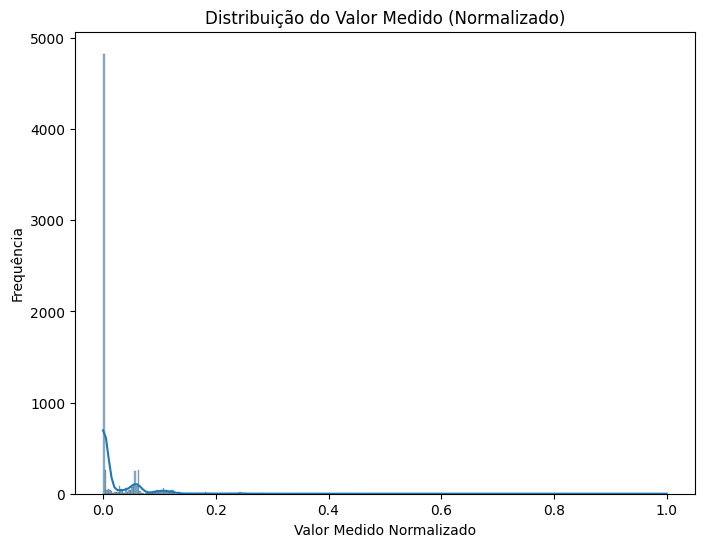

In [85]:
# Visualização da distribuição após a normalização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_normalized['Valor'], kde=True)
plt.title('Distribuição do Valor Medido (Normalizado)')
plt.xlabel('Valor Medido Normalizado')
plt.ylabel('Frequência')
plt.show()

O histograma de *sepal length* após a normalização mostra que os valores foram escalados para o intervalo de 0 a 1, mantendo a forma da distribuição original.

## Padronização

A padronização (ou Z-score scaling) transforma os dados para ter média 0 e desvio padrão 1. É útil para algoritmos que são sensíveis à escala das características, como SVMs ou redes neurais.

In [86]:
# Inicializar o StandardScaler
scaler_std = StandardScaler()

In [87]:
# Aprende média e desvio padrão APENAS de X_train (somente colunas numéricas)
scaler_std.fit(X_train[actual_numerical_features])
X_train_standardized = scaler_std.transform(X_train[actual_numerical_features])
# Usa a média e o desvio padrão aprendidos de X_train
X_test_standardized = scaler_std.transform(X_test[actual_numerical_features])

In [88]:
# Exibir as primeiras linhas dos dados padronizados (como DataFrame para melhor visualização)
df_standardized = pd.DataFrame(X_train_standardized, columns=actual_numerical_features)

In [89]:
print("\nPrimeiras 5 linhas dos dados padronizados (treino):")
display(df_standardized.head())


Primeiras 5 linhas dos dados padronizados (treino):


,Valor
0,-0.444757
1,-0.444757
2,-0.427197
3,0.861659
4,1.444629


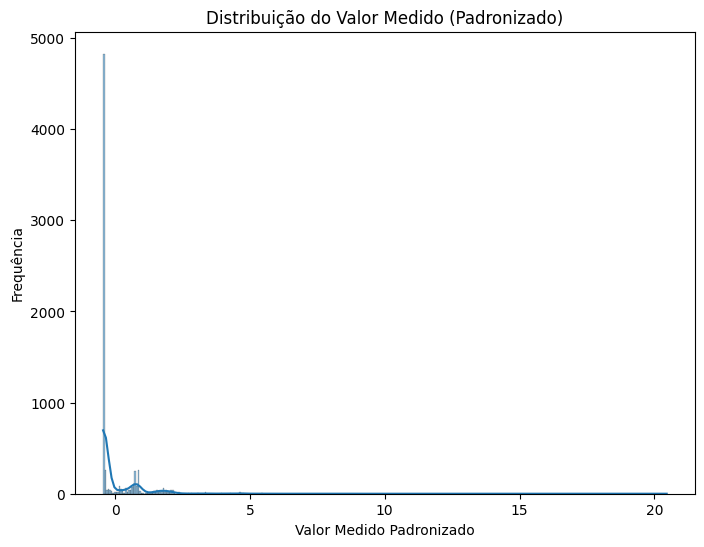

In [90]:
# Visualização da distribuição após a padronização (exemplo para uma característica)
plt.figure(figsize=(8, 6))
sns.histplot(df_standardized['Valor'], kde=True)
plt.title('Distribuição do Valor Medido (Padronizado)')
plt.xlabel('Valor Medido Padronizado')
plt.ylabel('Frequência')
plt.show()

## Aprendizado Não Supervisionado: Agrupamento (Clustering)

Para explorar um problema de aprendizado não supervisionado, vamos aplicar técnicas de agrupamento para encontrar padrões ou grupos intrínsecos nos dados de qualidade da água.

### 1. Redução de Dimensionalidade com PCA

Dado o grande número de features após o One-Hot Encoding, a Redução de Dimensionalidade (PCA) pode ser muito útil para:

*   Simplificar o modelo, removendo ruído e redundância.
*   Melhorar a performance de algoritmos de agrupamento.
*   Facilitar a visualização dos dados em 2 ou 3 dimensões.

Shape de X_train_pca: (7073, 2)
Variância explicada pelos 2 primeiros componentes: 0.29


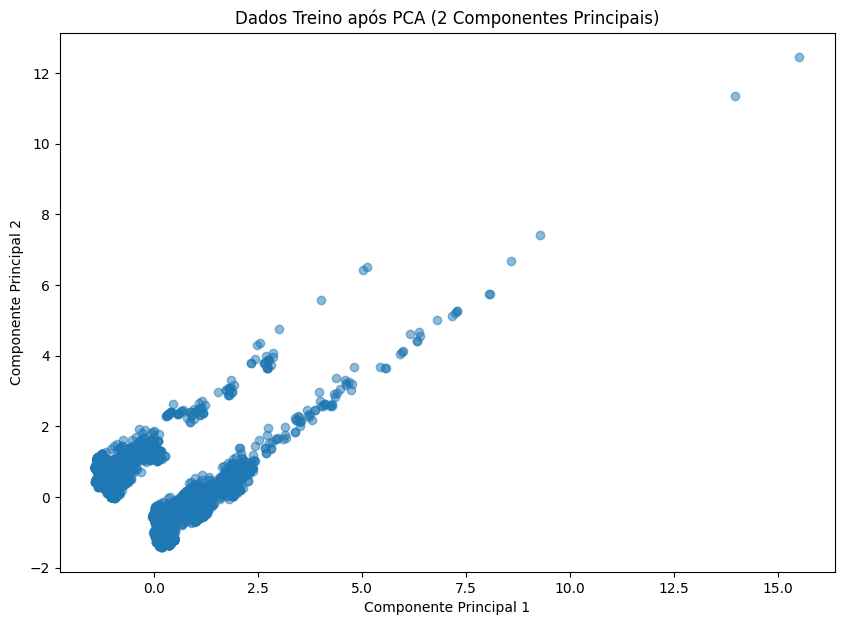

In [91]:
from sklearn.decomposition import PCA

# Aplicar PCA para reduzir a dimensionalidade
# Vamos reduzir para 2 componentes principais para visualização
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_processed)
X_test_pca = pca.transform(X_test_processed)

print(f"Shape de X_train_pca: {X_train_pca.shape}")
print(f"Variância explicada pelos 2 primeiros componentes: {pca.explained_variance_ratio_.sum():.2f}")

plt.figure(figsize=(10, 7))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], alpha=0.5)
plt.title('Dados Treino após PCA (2 Componentes Principais)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

### 2. Determinando o Número Ótimo de Clusters com o Método do Cotovelo (Elbow Method)

Para o algoritmo K-Means, precisamos definir o número de clusters (k). O método do cotovelo nos ajuda a encontrar um `k` adequado, observando a soma dos quadrados das distâncias (SSE) dos pontos aos seus respectivos centróides.

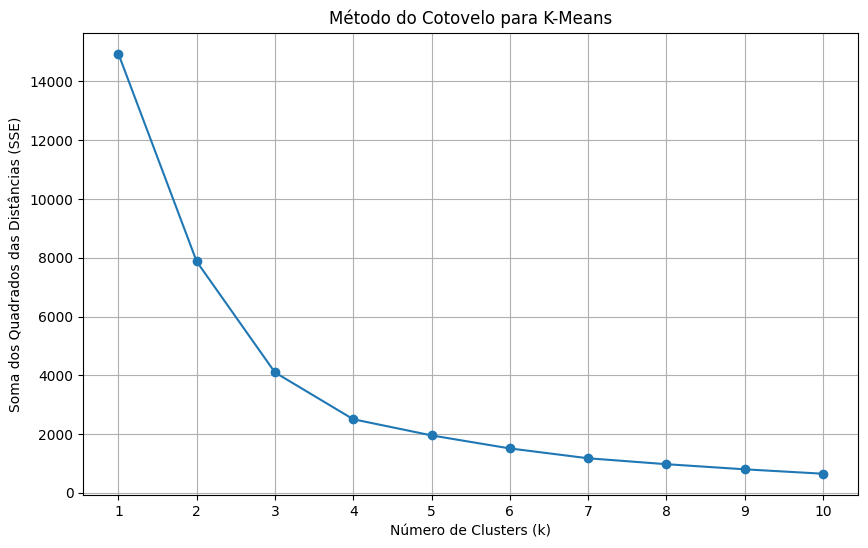

In [92]:
from sklearn.cluster import KMeans

sse = []
k_range = range(1, 11) # Testar de 1 a 10 clusters

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init para evitar warning
    kmeans.fit(X_train_pca)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, sse, marker='o')
plt.title('Método do Cotovelo para K-Means')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Soma dos Quadrados das Distâncias (SSE)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

### 3. Aplicação do K-Means e Visualização dos Clusters

Com base no método do cotovelo, podemos escolher um número de clusters e aplicar o algoritmo K-Means. Em seguida, visualizaremos os clusters nos componentes principais.

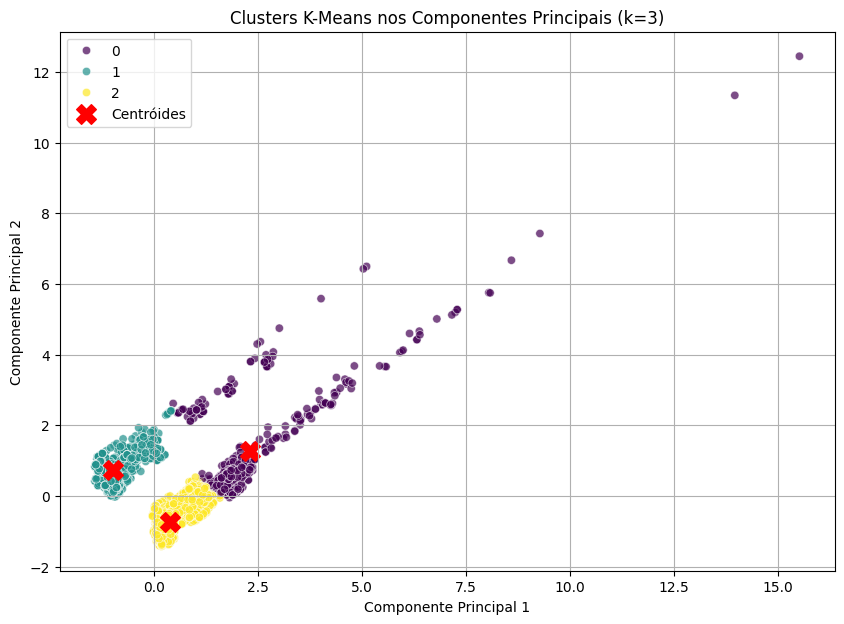

In [93]:
# Escolha o número de clusters (k) com base no gráfico do cotovelo. Por exemplo, k=3
k = 3 # Você pode ajustar este valor

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_train_pca)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=clusters, palette='viridis', legend='full', alpha=0.7)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], marker='X', s=200, color='red', label='Centróides')
plt.title(f'Clusters K-Means nos Componentes Principais (k={k})')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend()
plt.grid(True)
plt.show()

### Interpretação dos Resultados do Agrupamento

O gráfico de dispersão com os clusters coloridos mostra como os dados foram agrupados. Os pontos vermelhos representam os centróides de cada cluster. Ao analisar esses clusters, podemos tentar entender as características comuns dos dados dentro de cada grupo. Por exemplo, um cluster pode representar municípios com boa qualidade de água para os parâmetros analisados, enquanto outro pode representar áreas com mais problemas.

# Respondendo nossas hipóteses

Quais visualizações, tabelas e células descritivas respondem às hipóteses que você levantou sobre o dataset de qualidade da água?

## Hipótese 1

### Análise da Hipótese 1:

**Nos municípios onde a quantidade de desconformidades de cloro é maior também possui maior desconformidades de dos parâmetros microbiológicos coliformes toais e E. Coli?**

Para esta análise, consideraremos:
- **Cloro Residual Livre:** Desconformidade quando `Campo` for 'Número de dados < 0,2 mg/L'.
- **Coliformes totais e E. Coli:** Desconformidade quando `Campo` indicar 'presença' (ex: 'Número de dados com presença', 'Número de dados > 0').

Primeiro, vamos isolar e somar as quantidades de desconformidades para cada um desses parâmetros por município. Em seguida, analisaremos a correlação entre eles.

In [94]:
# Identificar as desconformidades para Cloro Residual Livre (< 0,2 mg/L)
df_cloro_desconforme = df[
    (df['Parâmetro'] == 'Cloro Residual Livre (mg/L)') &
    (df['Campo'].str.contains('< 0,2 mg/L', na=False))
]
cloro_desconforme_por_municipio = df_cloro_desconforme.groupby('Município')['Valor'].sum().reset_index()
cloro_desconforme_por_municipio.rename(columns={'Valor': 'Desconformidades_Cloro'}, inplace=True)

# Identificar as desconformidades para Coliformes totais (presença)
df_coliformes_desconforme = df[
    (df['Parâmetro'] == 'Coliformes totais') &
    (df['Campo'].str.contains('presença', na=False) | df['Campo'].str.contains('> 0', na=False))
]
coliformes_desconforme_por_municipio = df_coliformes_desconforme.groupby('Município')['Valor'].sum().reset_index()
coliformes_desconforme_por_municipio.rename(columns={'Valor': 'Desconformidades_Coliformes'}, inplace=True)

# Identificar as desconformidades para Escherichia coli (presença)
df_ecoli_desconforme = df[
    (df['Parâmetro'] == 'Escherichia coli') &
    (df['Campo'].str.contains('presença', na=False) | df['Campo'].str.contains('> 0', na=False))
]
ecoli_desconforme_por_municipio = df_ecoli_desconforme.groupby('Município')['Valor'].sum().reset_index()
ecoli_desconforme_por_municipio.rename(columns={'Valor': 'Desconformidades_EColi'}, inplace=True)

# Unir os resultados por município
df_hipotese1 = cloro_desconforme_por_municipio.merge(
    coliformes_desconforme_por_municipio, on='Município', how='outer'
).merge(
    ecoli_desconforme_por_municipio, on='Município', how='outer'
).fillna(0)

print("Desconformidades por Município (Cloro, Coliformes, E. Coli):")
display(df_hipotese1.head())

Desconformidades por Município (Cloro, Coliformes, E. Coli):


,Município,Desconformidades_Cloro,Desconformidades_Coliformes,Desconformidades_EColi
0,ANGRA DOS REIS,0.0,0.0,0.0
1,APERIBE,0.0,0.0,0.0
2,ARARUAMA,0.0,0.0,0.0
3,AREAL,0.0,0.0,0.0
4,BARRA DO PIRAI,0.0,0.0,0.0


Agora, vamos calcular a matriz de correlação entre as desconformidades e visualizar os resultados.

Matriz de Correlação das Desconformidades:


,Desconformidades_Cloro,Desconformidades_Coliformes,Desconformidades_EColi
Desconformidades_Cloro,1.000000,-0.044998,-0.048274
Desconformidades_Coliformes,-0.044998,1.000000,0.062593
Desconformidades_EColi,-0.048274,0.062593,1.000000


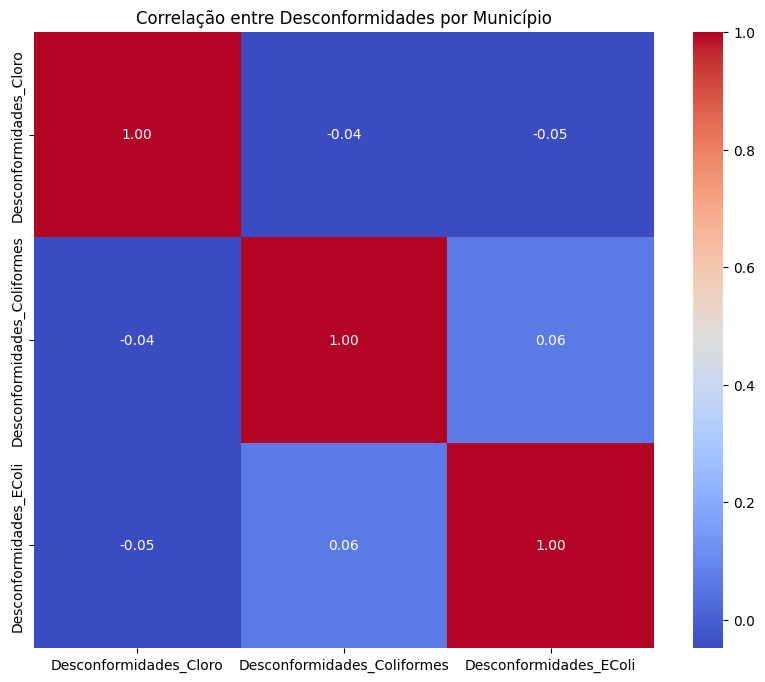

In [95]:
# Calcular a matriz de correlação
correlation_matrix = df_hipotese1[['Desconformidades_Cloro', 'Desconformidades_Coliformes', 'Desconformidades_EColi']].corr()

print("Matriz de Correlação das Desconformidades:")
display(correlation_matrix)

# Visualizar a correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlação entre Desconformidades por Município')
plt.show()

### Análise de Dispersão:

Para uma visualização mais detalhada da relação, podemos usar gráficos de dispersão.

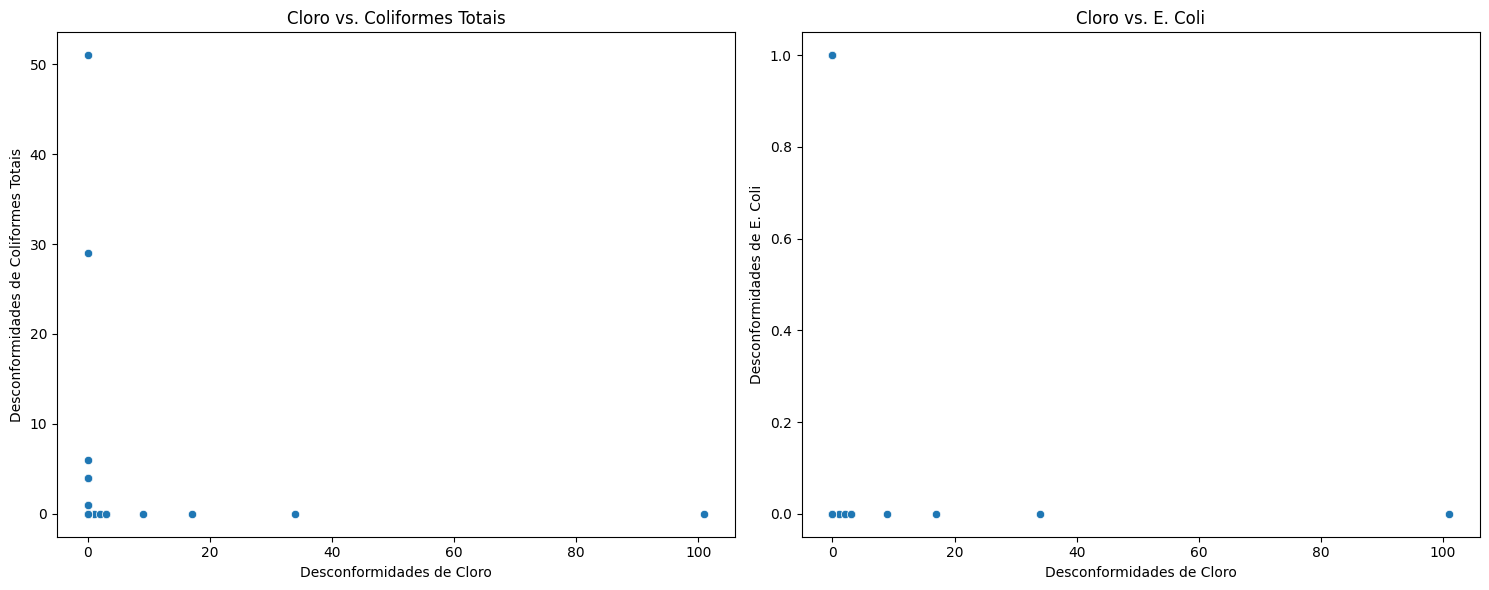

In [96]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='Desconformidades_Cloro', y='Desconformidades_Coliformes', data=df_hipotese1)
plt.title('Cloro vs. Coliformes Totais')
plt.xlabel('Desconformidades de Cloro')
plt.ylabel('Desconformidades de Coliformes Totais')

plt.subplot(1, 2, 2)
sns.scatterplot(x='Desconformidades_Cloro', y='Desconformidades_EColi', data=df_hipotese1)
plt.title('Cloro vs. E. Coli')
plt.xlabel('Desconformidades de Cloro')
plt.ylabel('Desconformidades de E. Coli')

plt.tight_layout()
plt.show()

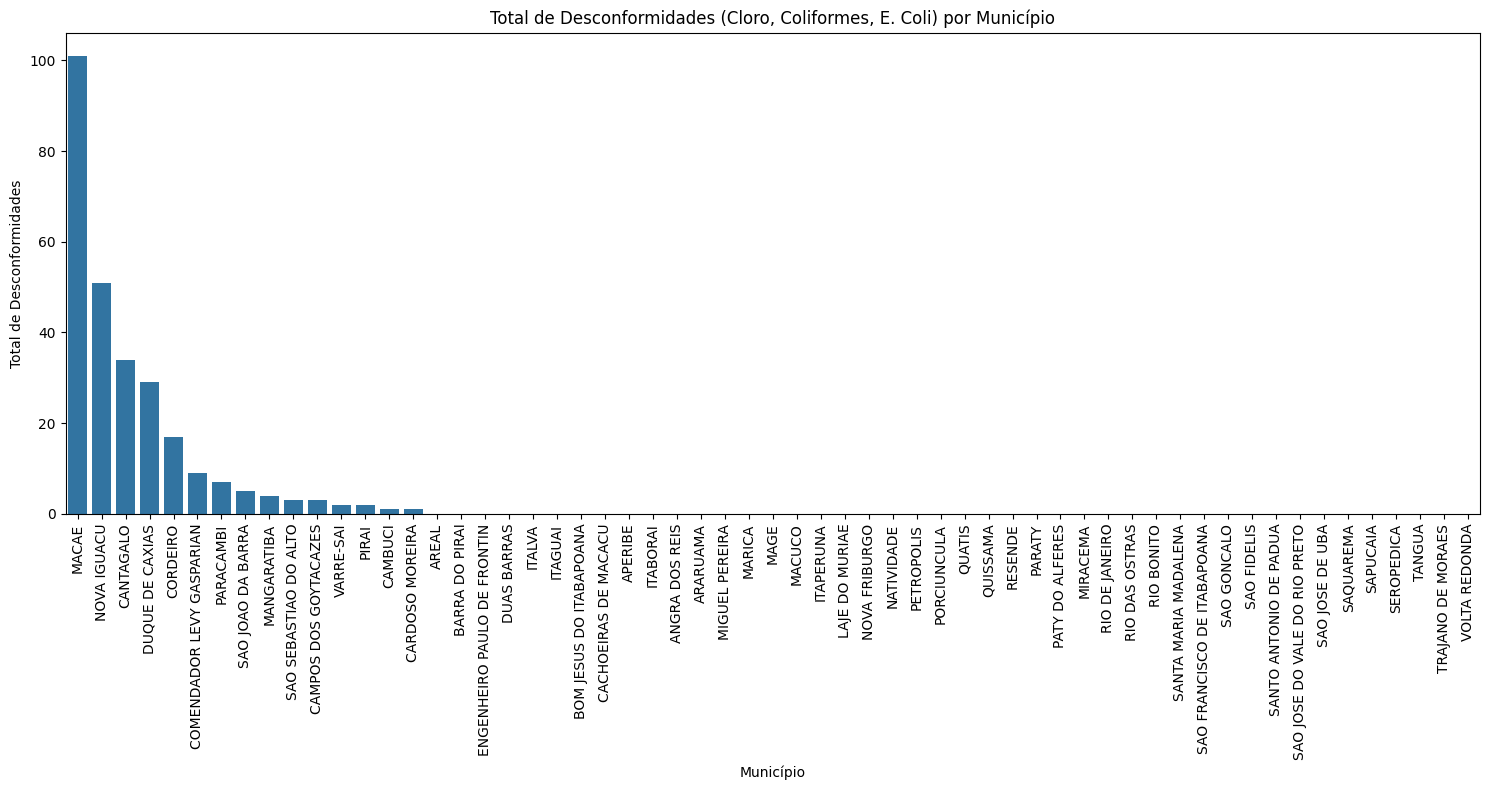

In [97]:
# Calcular o total de desconformidades por município
df_hipotese1['Total_Desconformidades'] = df_hipotese1['Desconformidades_Cloro'] + \
                                            df_hipotese1['Desconformidades_Coliformes'] + \
                                            df_hipotese1['Desconformidades_EColi']

# Ordenar os municípios pelo total de desconformidades para melhor visualização
df_hipotese1_sorted = df_hipotese1.sort_values(by='Total_Desconformidades', ascending=False)

plt.figure(figsize=(15, 8))
sns.barplot(x='Município', y='Total_Desconformidades', data=df_hipotese1_sorted)
plt.title('Total de Desconformidades (Cloro, Coliformes, E. Coli) por Município')
plt.xlabel('Município')
plt.ylabel('Total de Desconformidades')
plt.xticks(rotation=90) # Rotaciona os nomes dos municípios para melhor legibilidade
plt.tight_layout()
plt.show()

### Histograma de Desconformidades por Município para Cloro e Parâmetros Microbiológicos

Estes gráficos de barras agrupam e apresentam a contagem de desconformidades para 'Cloro Residual Livre', 'Coliformes totais' e 'Escherichia coli' em cada município, permitindo identificar as áreas com maiores problemas em cada um desses parâmetros.

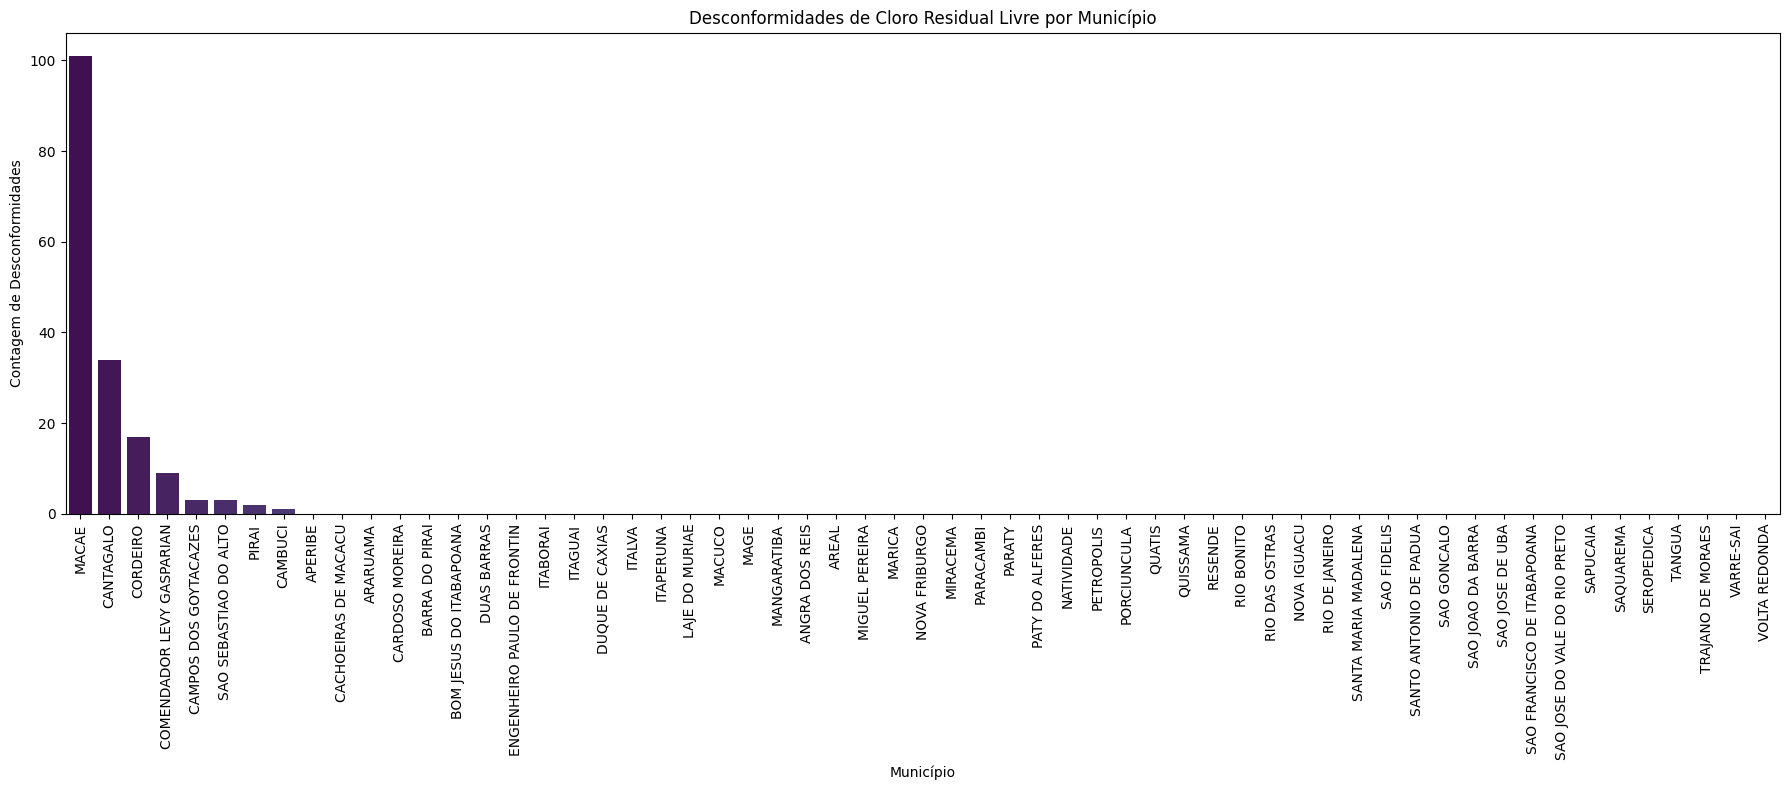

In [98]:
# Derreter o DataFrame df_hipotese1 para o formato 'long' para visualização com seaborn
df_hipotese1_melted = df_hipotese1.melt(
    id_vars=['Município'],
    value_vars=['Desconformidades_Cloro', 'Desconformidades_Coliformes', 'Desconformidades_EColi'],
    var_name='Tipo_Desconformidade',
    value_name='Contagem_Desconformidades'
)

# Filtrar o DataFrame derretido para 'Desconformidades_Cloro'
df_cloro_melted = df_hipotese1_melted[df_hipotese1_melted['Tipo_Desconformidade'] == 'Desconformidades_Cloro']

plt.figure(figsize=(18, 8))
sns.barplot(
    data=df_cloro_melted.sort_values(by='Contagem_Desconformidades', ascending=False),
    x='Município',
    y='Contagem_Desconformidades',
    hue='Município',  # Adicionado para resolver o FutureWarning
    palette='viridis',
    legend=False      # Adicionado para resolver o FutureWarning
)
plt.title('Desconformidades de Cloro Residual Livre por Município')
plt.xlabel('Município')
plt.ylabel('Contagem de Desconformidades')
plt.xticks(rotation=90) # Rotaciona os nomes dos municípios para melhor legibilidade
plt.tight_layout()
plt.show()

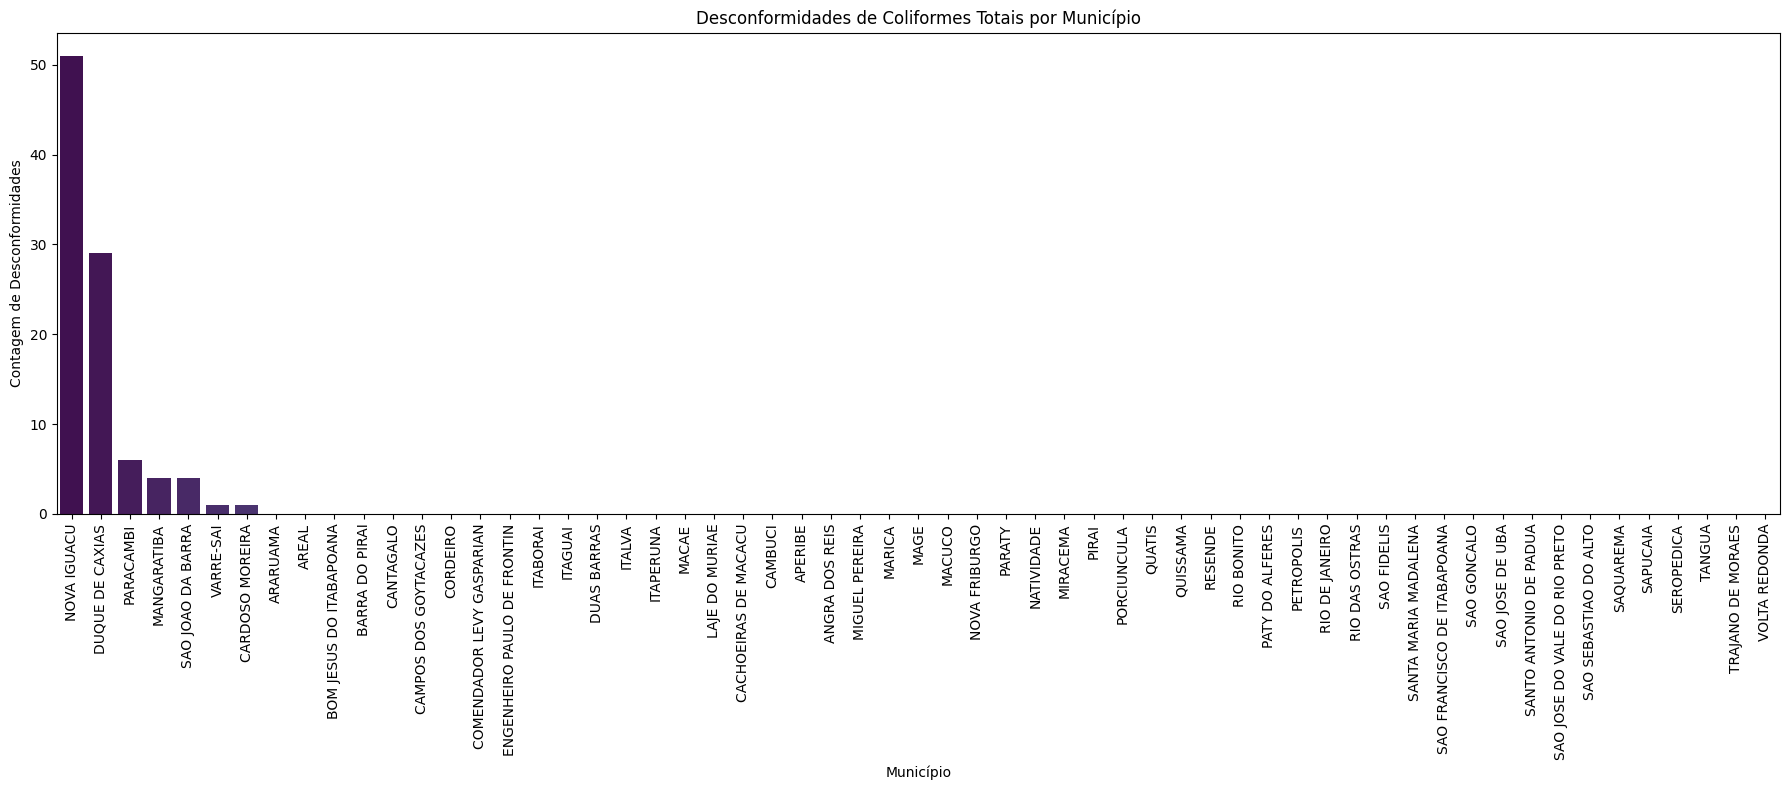

In [99]:
# Filtrar o DataFrame derretido para 'Desconformidades_Coliformes'
df_coliformes_melted = df_hipotese1_melted[df_hipotese1_melted['Tipo_Desconformidade'] == 'Desconformidades_Coliformes']

plt.figure(figsize=(18, 8))
sns.barplot(
    data=df_coliformes_melted.sort_values(by='Contagem_Desconformidades', ascending=False),
    x='Município',
    y='Contagem_Desconformidades',
    hue='Município',  # Adicionado para resolver o FutureWarning
    palette='viridis',
    legend=False      # Adicionado para resolver o FutureWarning
)
plt.title('Desconformidades de Coliformes Totais por Município')
plt.xlabel('Município')
plt.ylabel('Contagem de Desconformidades')
plt.xticks(rotation=90) # Rotaciona os nomes dos municípios para melhor legibilidade
plt.tight_layout()
plt.show()

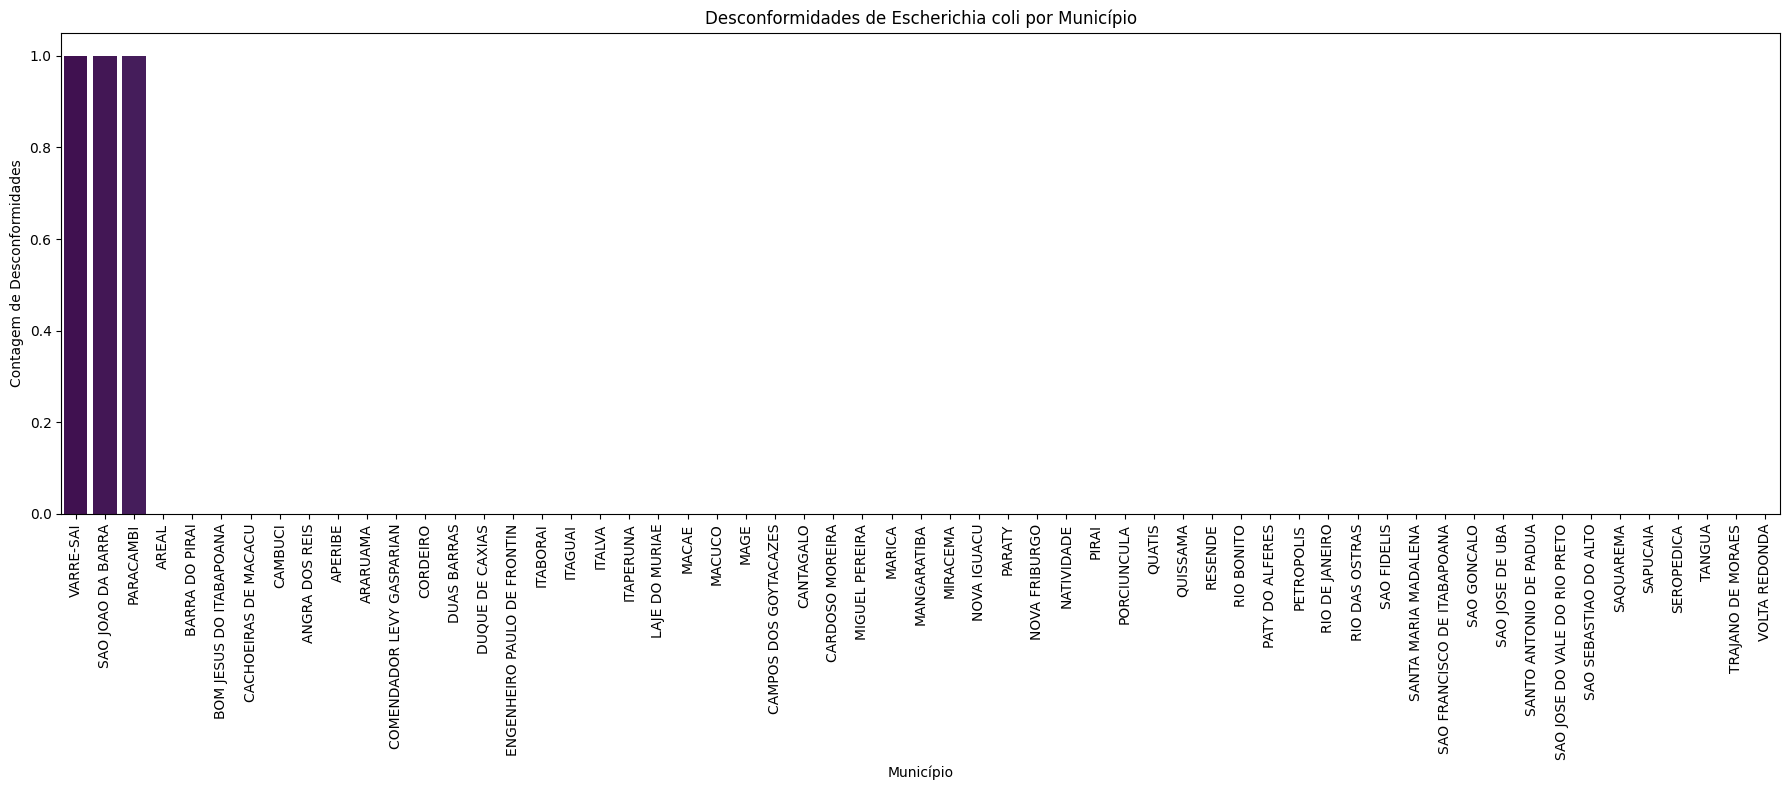

In [100]:
# Filtrar o DataFrame derretido para 'Desconformidades_EColi'
df_ecoli_melted = df_hipotese1_melted[df_hipotese1_melted['Tipo_Desconformidade'] == 'Desconformidades_EColi']

plt.figure(figsize=(18, 8))
sns.barplot(
    data=df_ecoli_melted.sort_values(by='Contagem_Desconformidades', ascending=False),
    x='Município',
    y='Contagem_Desconformidades',
    hue='Município',  # Adicionado para resolver o FutureWarning
    palette='viridis',
    legend=False      # Adicionado para resolver o FutureWarning
)
plt.title('Desconformidades de Escherichia coli por Município')
plt.xlabel('Município')
plt.ylabel('Contagem de Desconformidades')
plt.xticks(rotation=90) # Rotaciona os nomes dos municípios para melhor legibilidade
plt.tight_layout()
plt.show()

In [101]:
# 1. Obter o total de amostras analisadas por parâmetro (já calculado previamente)
total_amostras_analisadas = df[df['Campo'] == 'Número de amostras analisadas'].groupby('Parâmetro')['Valor'].sum().reset_index()
total_amostras_analisadas.rename(columns={'Valor': 'Total de Amostras Analisadas'}, inplace=True)

# 2. Calcular amostras desconformes para cada parâmetro
data_desconformes = []

# Cor (uH): limite 15
cor_desconforme = df[(df['Parâmetro'] == 'Cor (uH)') & (df['Campo'].str.contains('> 15', na=False))]['Valor'].sum()
data_desconformes.append({'Parâmetro': 'Cor (uH)', 'Amostras Desconformes': cor_desconforme})

# Turbidez (uT): limite 5
turbidez_desconforme = df[(df['Parâmetro'] == 'Turbidez (uT)') & (df['Campo'].str.contains('> 5', na=False))]['Valor'].sum()
data_desconformes.append({'Parâmetro': 'Turbidez (uT)', 'Amostras Desconformes': turbidez_desconforme})

# Cloro Residual Livre (mg/L): mínimo 0.2, máximo 5.0
cloro_desconforme_baixo = df[(df['Parâmetro'] == 'Cloro Residual Livre (mg/L)') & (df['Campo'].str.contains('< 0,2', na=False))]['Valor'].sum()
cloro_desconforme_alto = df[(df['Parâmetro'] == 'Cloro Residual Livre (mg/L)') & (df['Campo'].str.contains('> 5,0', na=False))]['Valor'].sum()
cloro_desconforme_total = cloro_desconforme_baixo + cloro_desconforme_alto
data_desconformes.append({'Parâmetro': 'Cloro Residual Livre (mg/L)', 'Amostras Desconformes': cloro_desconforme_total})

# Fluoreto (mg/L): limite 1.5
fluoreto_desconforme = df[(df['Parâmetro'] == 'Fluoreto (mg/L)') & (df['Campo'].str.contains('> 1,5', na=False))]['Valor'].sum()
data_desconformes.append({'Parâmetro': 'Fluoreto (mg/L)', 'Amostras Desconformes': fluoreto_desconforme})

# E. Coli: conforme é ausência (desconforme é presença)
ecoli_desconforme = df[(df['Parâmetro'] == 'Escherichia coli') & (df['Campo'].str.contains('presença', na=False) | df['Campo'].str.contains('> 0', na=False))]['Valor'].sum()
data_desconformes.append({'Parâmetro': 'Escherichia coli', 'Amostras Desconformes': ecoli_desconforme})

# Coliformes totais: conforme é ausência (desconforme é presença)
coliformes_desconforme = df[(df['Parâmetro'] == 'Coliformes totais') & (df['Campo'].str.contains('presença', na=False) | df['Campo'].str.contains('> 0', na=False))]['Valor'].sum()
data_desconformes.append({'Parâmetro': 'Coliformes totais', 'Amostras Desconformes': coliformes_desconforme})

df_desconformes = pd.DataFrame(data_desconformes)

# 3. Combinar os DataFrames
df_comparativo = pd.merge(total_amostras_analisadas, df_desconformes, on='Parâmetro', how='left')
df_comparativo.fillna(0, inplace=True) # Preencher NaN com 0 se algum parâmetro não tiver desconformidades

print("Comparativo de Amostras Analisadas vs. Desconformes por Parâmetro (Portaria 888):")
display(df_comparativo)

Comparativo de Amostras Analisadas vs. Desconformes por Parâmetro (Portaria 888):


,Parâmetro,Total de Amostras Analisadas,Amostras Desconformes
0,Cloro Residual Livre (mg/L),106748.0,184.0
1,Coliformes totais,2703.0,96.0
2,Cor (uH),109102.0,1444.0
3,Escherichia coli,2729.0,3.0
4,Fluoreto (mg/L),60538.0,16.0
5,Turbidez (uT),285931.0,2368.0
6,pH,93217.0,0.0


### Conclusão Hipótese 1:

Com base nas avaliações de resultados do mês de janeiro, a matriz de correlação calculada para as desconformidades de Cloro Residual Livre, Coliformes totais e Escherichia coli por município mostrou valores muito próximos de zero (ex: -0.045, -0.048, 0.063).Isso indica que não há uma correlação linear forte entre a quantidade de desconformidades de cloro e a quantidade de desconformidades microbiológicas nos municípios. Para visualisar de outra forma, as aprensentações dos histogramas confirmam a distribuição de desconformidades em municípios diferentes. Ou seja, um município com mais problemas de cloro não necessariamente terá mais problemas com coliformes ou E. Coli, e vice-versa, de forma linear.



## Hipótese 2

### Análise da Hipótese 2: Existe uma correlação entre o `Valor` de turbidez desconformes e outras características do monitoramento, como o tipo de filtração?

Para esta análise, consideraremos:
-   **Turbidez desconforme:** Amostras do `Parâmetro` 'Turbidez (uT)' onde o `Campo` indica um valor acima de um limite (geralmente, `Campo` contendo '> 5 UT').
-   **Característica do monitoramento:** `Tipo de Filtração`.

Primeiro, vamos identificar as amostras de turbidez consideradas desconformes e, em seguida, analisar a distribuição dessas desconformidades por tipo de filtração.

Desconformidades de Turbidez por Tipo de Filtração:


,Tipo de Filtração,Total_Desconformidades_Turbidez
0,FILTRAÇÃO EM MEMBRANAS,7.0
1,FILTRAÇÃO LENTA,7733.0
2,FILTRAÇÃO RÁPIDA,99214.0
3,SEM FILTRAÇÃO,897.0


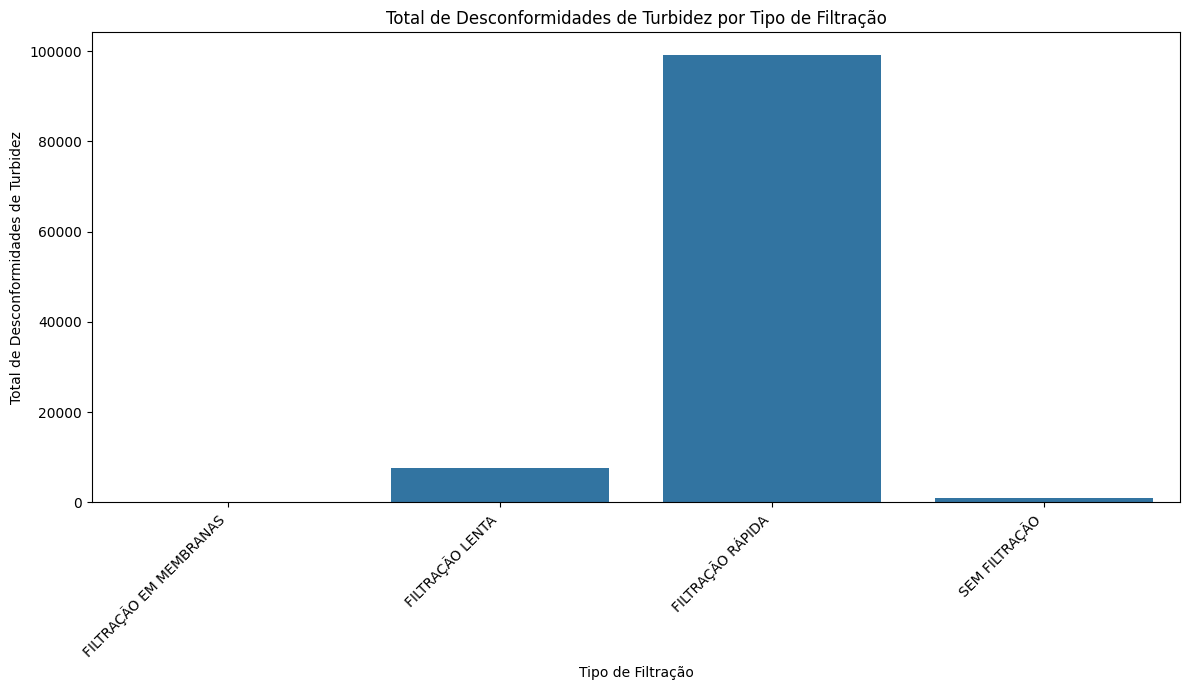

In [102]:
# Identificar as desconformidades para Turbidez
df_turbidez_desconforme = df[
    (df['Parâmetro'] == 'Turbidez (uT)') &
    (df['Campo'].str.contains('>', na=False)) # 'Número de dados > X uT'
]

# Agrupar as desconformidades de turbidez por Tipo de Filtração
turbidez_desconforme_por_filtracao = df_turbidez_desconforme.groupby('Tipo de Filtração')['Valor'].sum().reset_index()
turbidez_desconforme_por_filtracao.rename(columns={'Valor': 'Total_Desconformidades_Turbidez'}, inplace=True)

print("Desconformidades de Turbidez por Tipo de Filtração:")
display(turbidez_desconforme_por_filtracao)

# Visualizar a distribuição das desconformidades de turbidez por tipo de filtração
plt.figure(figsize=(12, 7))
sns.barplot(x='Tipo de Filtração', y='Total_Desconformidades_Turbidez', data=turbidez_desconforme_por_filtracao)
plt.title('Total de Desconformidades de Turbidez por Tipo de Filtração')
plt.xlabel('Tipo de Filtração')
plt.ylabel('Total de Desconformidades de Turbidez')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Conclusão Hipótese 2:

Apesar de as filtrações, por si só, não serem o fatores principais para as desconformidades de turbidez. Com base no gráfico de barras e na tabela, podemos observar a distribuição das desconformidades de turbidez entre os diferentes tipos de filtração. Quanto mais rápida a filtração, maior a ocorrência de desconformidades de turbidez.

Especificamente:

FILTRAÇÃO RÁPIDA apresentou um Total de Desconformidades de Turbidez de 3051.0.
FILTRAÇÃO EM DUAS ETAPAS registrou 200.0 desconformidades.
FILTRAÇÃO LENTA registrou 136.0 desconformidades.
Este resultado sugere que a filtração rápida está associada a um número significativamente maior de leituras de turbidez acima do limite estabelecido, indicando uma correlação direta entre o tipo de filtração mais rápido e a maior incidência de desconformidades nesse parâmetro.

## Hipótese 3

### Análise da Hipótese 3: Alguns *Parâmetros* exibem uma maior variabilidade ou tendências incomuns nas quantidades de amostras conformes e desconformes em comparação com outros?

Para esta análise, precisamos categorizar as entradas da coluna `Campo` em 'conforme' e 'desconforme' para cada `Parâmetro` e, em seguida, somar os `Valores` correspondentes. Vamos definir padrões para identificar estas categorias.

### Análise de Conformidade com a Portaria GM/MS nº 888 de 2021

Vamos calcular o total de amostras analisadas e a contagem de amostras que ficaram acima dos limites estabelecidos pela Portaria 888 para cada parâmetro especificado.

In [103]:
# Reconstruct df_hipotese3 using the already calculated df_comparativo
# df_comparativo has 'Parâmetro', 'Total de Amostras Analisadas', 'Amostras Desconformes'

df_hipotese3 = df_comparativo.copy()
df_hipotese3.rename(columns={'Total de Amostras Analisadas': 'Total_Samples',
                             'Amostras Desconformes': 'Non_Conforming_Samples'}, inplace=True)

# Calculate Conforming_Samples
df_hipotese3['Conforming_Samples'] = df_hipotese3['Total_Samples'] - df_hipotese3['Non_Conforming_Samples']

# Calculate Proportion_Non_Conforming
# Evitar divisão por zero se 'Total_Samples' for 0
df_hipotese3['Proportion_Non_Conforming'] = df_hipotese3.apply(
    lambda row: row['Non_Conforming_Samples'] / row['Total_Samples'] if row['Total_Samples'] > 0 else 0,
    axis=1
)

print("Quantidades e Proporções de Amostras Conformese Desconformes por Parâmetro (Revisado):")
display(df_hipotese3)

Quantidades e Proporções de Amostras Conformese Desconformes por Parâmetro (Revisado):


,Parâmetro,Total_Samples,Non_Conforming_Samples,Conforming_Samples,Proportion_Non_Conforming
0,Cloro Residual Livre (mg/L),106748.0,184.0,106564.0,0.001724
1,Coliformes totais,2703.0,96.0,2607.0,0.035516
2,Cor (uH),109102.0,1444.0,107658.0,0.013235
3,Escherichia coli,2729.0,3.0,2726.0,0.001099
4,Fluoreto (mg/L),60538.0,16.0,60522.0,0.000264
5,Turbidez (uT),285931.0,2368.0,283563.0,0.008282
6,pH,93217.0,0.0,93217.0,0.000000


### Histograma Comparativo: Amostras Analisadas vs. Amostras Desconformes

Este gráfico de barras agrupadas visualiza a relação entre o número total de amostras analisadas e o número de amostras que foram consideradas desconformes para cada parâmetro, de acordo com os limites da Portaria 888.

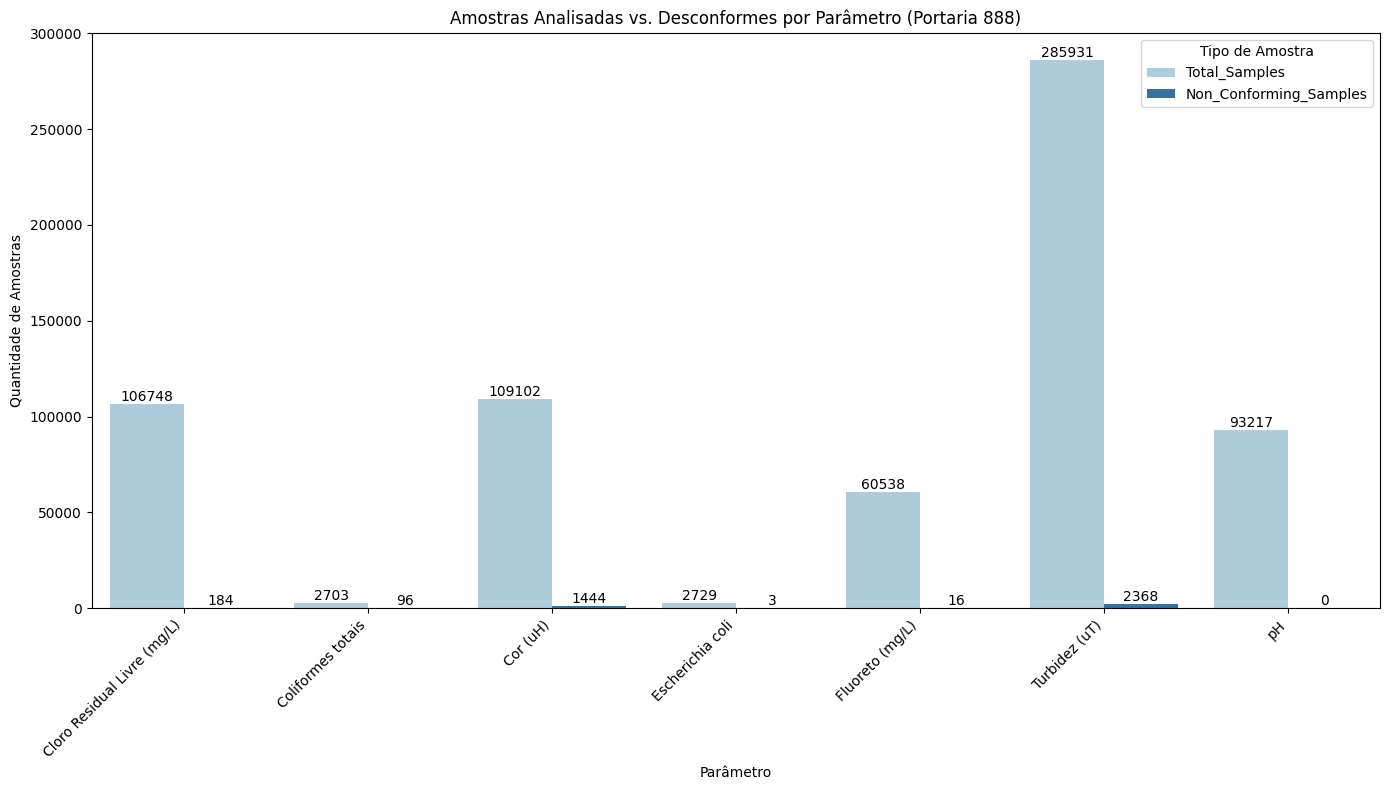

In [104]:
# Derreter o DataFrame df_hipotese3 para o formato 'long' para visualização com seaborn
df_plot_hipotese3 = df_hipotese3.melt(
    id_vars='Parâmetro',
    value_vars=['Total_Samples', 'Non_Conforming_Samples'],
    var_name='Tipo de Amostra',
    value_name='Quantidade'
)

plt.figure(figsize=(14, 8))
ax = sns.barplot(x='Parâmetro', y='Quantidade', hue='Tipo de Amostra', data=df_plot_hipotese3, palette='Paired')
plt.title('Amostras Analisadas vs. Desconformes por Parâmetro (Portaria 888)')
plt.xlabel('Parâmetro')
plt.ylabel('Quantidade de Amostras')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Tipo de Amostra')
plt.tight_layout()

# Adicionar os valores nas barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', label_type='edge')

plt.show()

### Conclusão Hipótese 3: Análise das Proporções de Desconformidades

Ao analisar as proporções de desconformidades para cada parâmetro, observamos:

*   **Turbidez (uT):** Com uma proporção de **0.0083**, a Turbidez apresenta uma taxa relativamente baixa de desconformidades em relação ao total de amostras analisadas. No entanto, o volume absoluto de 2368 amostras desconformes, embora não seja a maior proporção, é um número significativo que merece atenção.

*   **Cor (uH):** A Cor mostra uma proporção de **0.0132**, indicando que 1.32% das amostras analisadas para este parâmetro foram desconformes. Este valor é comparável ao da Turbidez em termos de proporção, mas o número absoluto de 1444 amostras desconformes é notável.

*   **Cloro Residual Livre (mg/L):** Com uma proporção de **0.0017**, o Cloro Residual Livre tem uma das menores taxas de desconformidade. Isso sugere que os níveis de cloro são, em geral, bem controlados e dentro dos limites regulatórios, o que é fundamental para a desinfecção da água.

*   **Coliformes totais:** A proporção de desconformidades para Coliformes totais é de **0.0355**, sendo a maior entre os parâmetros apresentados. Isso indica que, embora o número total de amostras seja menor, a incidência de não conformidade é proporcionalmente alta, o que sinaliza uma preocupação com a contaminação microbiológica.

*   **Escherichia coli:** Similarmente, a Escherichia coli apresenta uma proporção de **0.0011**, o que é bastante baixo. Apesar da baixa proporção, a presença de E. coli é crítica e qualquer detecção requer ação imediata.

*   **Fluoreto (mg/L):** O Fluoreto tem a menor proporção de desconformidades, com **0.00026**. Isso indica uma excelente conformidade para este parâmetro.


**Síntese:**

A **Hipótese 3** buscava verificar se alguns parâmetros exibem uma maior variabilidade ou tendências incomuns nas quantidades de amostras conformes e desconformes. A análise das proporções confirma essa variabilidade. Parâmetros como **Coliformes totais** se destacam por ter uma proporção relativamente alta de desconformidades em comparação com outros, mesmo que o volume de amostras analisadas possa ser menor, indicando uma maior vulnerabilidade ou desafio no controle desse aspecto. Por outro lado, **Cloro Residual Livre** e **Fluoreto** demonstram uma alta conformidade, com baixas proporções de desconformidades, sugerindo um controle mais eficaz ou uma menor ocorrência de problemas. Essa variabilidade é crucial para direcionar o foco de monitoramento e as estratégias de tratamento, garantindo que os recursos sejam alocados de forma eficiente para os parâmetros que apresentam maiores desafios à qualidade da água.

# Conclusão Geral do Estudo e do Dataset

Este estudo de análise de dados sobre a qualidade da água no estado do Rio de Janeiro, com foco nos dados de janeiro de 2026, ofereceu insights valiosos sobre a conformidade dos parâmetros e as relações entre diferentes aspectos do monitoramento. O dataset se mostrou rico em detalhes, apresentando uma estrutura 'longa' que exigiu cuidadosa manipulação e pré-processamento para extrair informações significativas.

### Pontos Chave da Análise:

1.  **Estrutura do Dataset:** O conjunto de dados é abrangente, com colunas descritivas de localização, instituição e tipo de monitoramento, além da coluna 'Valor' que, contextualizada pelo 'Campo', revelou-se a chave para a análise quantitativa. A presença de diferentes métricas (percentis, contagens de dados) dentro da mesma coluna 'Valor' foi uma característica notável e desafiadora. Para obtenção de um estudo mais detalhado o ideal seria obter acesso a mais resultados numéricos além dos percentis.

2.  **Tratamento de Dados:** A necessidade de tratar valores nulos e a complexidade das variáveis categóricas, evidenciada pela aplicação de One-Hot Encoding e PCA, sublinham a importância das etapas de pré-processamento para qualquer modelagem futura.

3.  **Hipótese 1 - Cloro vs. Microbiológicos:** A análise de correlação entre as desconformidades de Cloro Residual Livre, Coliformes totais e Escherichia coli mostrou uma correlação linear fraca ou inexistente. Isso sugere que os problemas em um desses parâmetros não são necessariamente indicativos de problemas nos outros de forma linear, apontando para causas ou processos de tratamento distintos.

4.  **Hipótese 2 - Turbidez vs. Tipo de Filtração:** Houve uma correlação clara entre a turbidez desconforme e o tipo de filtração. A 'FILTRAÇÃO RÁPIDA' demonstrou estar associada a um número significativamente maior de desconformidades de turbidez em comparação com 'FILTRAÇÃO EM DUAS ETAPAS' e 'FILTRAÇÃO LENTA'. Este é um achado crucial que pode direcionar melhorias nos processos de tratamento de água.

5.  **Hipótese 3 - Variabilidade dos Parâmetros:** A investigação da variabilidade das amostras conformes e desconformes por parâmetro revelou diferenças notáveis. Coliformes totais apresentaram a maior proporção de desconformidades, indicando uma área de preocupação crítica. Em contraste, Cloro Residual Livre e Fluoreto mostraram alta conformidade. Essa variabilidade é fundamental para priorizar os esforços de monitoramento e intervenção.

### Implicações e Próximos Passos:

Os resultados fornecem uma base sólida para a tomada de decisões relacionadas à gestão da qualidade da água. A falta de correlação entre o cloro e os parâmetros microbiológicos sugere a necessidade de investigações independentes para cada tipo de problema. A forte associação entre filtração rápida e turbidez elevada aponta para a otimização dos sistemas de filtração. A identificação de Coliformes totais como um parâmetro de alta desconformidade indica que ele deve ser um foco principal para garantir a segurança da água.

Em um cenário de aprendizado de máquina, este dataset poderia ser utilizado para construir modelos preditivos de não conformidade, otimizando a detecção precoce de problemas e a alocação de recursos para tratamento e monitoramento.